### PHẦN 1.1: Thiết lập môi trường và Cài đặt các gói thư viện (Environment Setup)

> Môi trường phát triển là tập hợp các công cụ và phần mềm cho phép chúng ta viết, kiểm tra và gỡ lỗi mã. Python là ngôn ngữ được sử dụng phổ biến nhất cho Machine Learning nhờ cú pháp đơn giản, tính linh hoạt và hệ sinh thái thư viện vô cùng mạnh mẽ.
>
> Mặc dù các môi trường đám mây như Google Colab thường đã cài đặt sẵn phần lớn các thư viện cốt lõi cho Data Science (như `numpy`, `pandas`, `matplotlib`, `scikit-learn`), chúng ta vẫn cần cài đặt bổ sung hoặc cập nhật một số công cụ chuyên dụng để phục vụ cho các kỹ thuật Học sâu (Deep Learning) nâng cao trong chương này:
>
> 1. **TensorFlow & Keras**: Nền tảng chính để xây dựng các Mạng nơ-ron tích chập (CNN). Kể từ phiên bản 2.4, Keras đã được tích hợp chặt chẽ vào TensorFlow và trở thành API cấp cao chính thức của nó. Việc cài đặt TensorFlow sẽ tự động cài đặt Keras đi kèm.
> 2. **Keras Tuner**: Một thư viện cực kỳ hữu ích giúp tự động hóa quá trình tìm kiếm và tinh chỉnh các siêu tham số (hyperparameters) cho mạng nơ-ron thay vì chúng ta phải thử nghiệm thủ công.
> 3. **TensorBoard Plugin**: TensorBoard là một công cụ trực quan hóa tương tác tuyệt vời để theo dõi các đường cong học tập (loss/accuracy), hình dung biểu đồ tính toán và phân tích tài nguyên. Chúng ta sẽ cài thêm plugin `tensorboard-plugin-profile` để đo lường và xác định các "nút thắt cổ chai" (bottlenecks) về tốc độ của mô hình.
>
> *Lưu ý: Chúng ta sử dụng lệnh `%pip install` trực tiếp trong Jupyter Notebook để cài đặt các thư viện này vào môi trường thực thi hiện tại.*

In [22]:
import sys
import platform

print(f"Phiên bản Python hiện tại: {platform.python_version()}")
print("Đang tiến hành kiểm tra và cài đặt các thư viện bổ sung...\n")

# 1. Cài đặt Keras Tuner để hỗ trợ tinh chỉnh siêu tham số mô hình Keras
# Sử dụng -q (quiet) để ẩn các log không cần thiết, -U (upgrade) để cài bản mới nhất
%pip install -q -U keras-tuner

# 2. Cài đặt plugin Profile cho TensorBoard để lập hồ sơ hiệu suất mạng nơ-ron
%pip install -q -U tensorboard-plugin-profile

# 3. Cài đặt thư viện TensorFlow Datasets để tải nhanh các bộ dữ liệu chuẩn (như CIFAR-10, Fashion MNIST)
%pip install -q -U tensorflow-datasets

# 4. (Tùy chọn) Cập nhật TensorFlow và các thư viện cơ bản nếu bạn chạy trên máy cá nhân
# (Nếu chạy trên Colab, bạn có thể bỏ qua dòng dưới đây vì hệ thống đã có sẵn bản tối ưu)
# %pip install -q -U tensorflow numpy pandas matplotlib scikit-learn

print("\nCài đặt hoàn tất! Môi trường đã sẵn sàng để chuyển sang bước Import thư viện.")

Phiên bản Python hiện tại: 3.12.13
Đang tiến hành kiểm tra và cài đặt các thư viện bổ sung...


Cài đặt hoàn tất! Môi trường đã sẵn sàng để chuyển sang bước Import thư viện.


### PHẦN 1.2: Khai báo thư viện và Thiết lập cấu hình ban đầu (Imports & Configuration)
> Sau khi đã cài đặt xong các công cụ cần thiết, bước tiếp theo là khai báo (import) chúng vào không gian làm việc. Trong phần này, chúng ta sẽ thực hiện các cấu hình quan trọng sau:
>
> 1. **Khai báo thư viện cốt lõi:** Import `tensorflow` (thường được viết tắt là `tf`), Keras API nằm trong `tf.keras`, `numpy` để xử lý mảng tính toán, và `matplotlib.pyplot` để trực quan hóa dữ liệu và vẽ đồ thị.
> 2. **Thiết lập hạt giống ngẫu nhiên (Random Seed):** Các mạng nơ-ron khởi tạo trọng số ngẫu nhiên ban đầu. Việc thiết lập một hạt giống ngẫu nhiên cố định (ví dụ như số `42` - con số mang ý nghĩa vui vui là "Câu trả lời cho vạn vật") giúp đảm bảo kết quả huấn luyện có thể tái lập được (reproducible) giống hệt nhau trong mỗi lần bạn chạy lại notebook này. Chúng ta sẽ sử dụng hàm `tf.keras.utils.set_random_seed()` cực kỳ tiện lợi vì nó đặt seed cho cả TensorFlow, Python, và NumPy cùng lúc.
> 3. **Kiểm tra và Cấu hình phần cứng (GPU):** Việc huấn luyện các mạng CNN cho Thị giác máy tính đòi hỏi rất nhiều tài nguyên. Chạy trên GPU có thể giảm thời gian từ hàng giờ xuống còn vài phút. Đoạn mã dưới đây sẽ kiểm tra xem TensorFlow có nhận diện được GPU nào không. Ngoài ra, mặc định TensorFlow sẽ chiếm toàn bộ RAM của GPU. Chúng ta sẽ thiết lập chế độ "cấp phát bộ nhớ động" (`memory_growth`) để nó chỉ lấy thêm bộ nhớ khi thực sự cần.

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import keras_tuner as kt
import os
import random
from pathlib import Path

# 1. Cố định hạt giống ngẫu nhiên để tái lập kết quả
seed_value = 42
tf.keras.utils.set_random_seed(seed_value) #
print(f"Đã thiết lập Random Seed: {seed_value}")

# 2. Kiểm tra phiên bản thư viện
print("Phiên bản TensorFlow:", tf.__version__)

# 3. Kiểm tra và thiết lập thiết bị GPU
physical_gpus = tf.config.list_physical_devices("GPU")
if physical_gpus:
    print(f"Tuyệt vời! Phát hiện thấy {len(physical_gpus)} GPU:")
    for gpu in physical_gpus:
        print(f" - {gpu.name}")

    # Cấu hình cấp phát bộ nhớ GPU động (Memory Growth)
    try:
        for gpu in physical_gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Đã bật chế độ tự động mở rộng bộ nhớ GPU (Memory Growth).")
    except RuntimeError as e:
        # Việc thiết lập Memory Growth phải được thực hiện trước khi khởi tạo bất kỳ tensor nào
        print("Lưu ý khi cấu hình GPU:", e)
else:
    print("CẢNH BÁO: Không tìm thấy GPU! Quá trình huấn luyện CNN sẽ rất chậm trên CPU.")
    print("Mẹo: Nếu bạn đang dùng Google Colab, hãy vào menu Runtime -> Change runtime type -> Hardware accelerator -> chọn GPU.")

Đã thiết lập Random Seed: 42
Phiên bản TensorFlow: 2.19.0
Tuyệt vời! Phát hiện thấy 1 GPU:
 - /physical_device:GPU:0
Đã bật chế độ tự động mở rộng bộ nhớ GPU (Memory Growth).


### PHẦN 2.1: Tải tập dữ liệu hình ảnh (Loading Dataset)

> Trong bài thực hành này, chúng ta sẽ sử dụng tập dữ liệu **Fashion MNIST**. Đây là một tập dữ liệu tiêu chuẩn thường được dùng để thay thế cho tập MNIST truyền thống (nhận dạng chữ số) do có độ phức tạp cao hơn. Tập dữ liệu này bao gồm 70.000 hình ảnh thang độ xám (grayscale) có kích thước $28 \times 28$ pixel, đại diện cho các mặt hàng thời trang và được chia thành 10 lớp.
>
> Keras cung cấp sẵn một số hàm tiện ích để lấy và tải các tập dữ liệu phổ biến một cách dễ dàng. Tập dữ liệu khi tải về đã được xáo trộn và chia sẵn thành hai phần: một tập huấn luyện (60.000 hình ảnh) và một tập kiểm tra (10.000 hình ảnh). Tuy nhiên, trong học máy thực tế, chúng ta luôn cần một tập xác thực (validation set) để theo dõi và tránh quá khớp (overfitting) trong quá trình huấn luyện. Do đó, chúng ta sẽ giữ lại 5.000 hình ảnh cuối cùng từ tập huấn luyện để làm tập xác thực.
>
> Khác với dữ liệu từ Scikit-Learn (thường là mảng 1D phẳng), mỗi hình ảnh tải qua Keras được giữ nguyên cấu trúc không gian là một mảng $28 \times 28$. Hơn nữa, cường độ pixel ban đầu được biểu diễn dưới dạng số nguyên (từ 0 đến 255). Đồng thời, ta cũng cần định nghĩa danh sách tên các mặt hàng (class names) tương ứng với nhãn số từ 0 đến 9 để dễ dàng trực quan hóa sau này.

In [24]:
# Gọi hàm tiện ích của Keras để tải tập dữ liệu Fashion MNIST
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data() #

# Giải nén tuple được trả về thành tập huấn luyện và tập kiểm tra ban đầu
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist #

# Trích xuất 5.000 mẫu cuối cùng từ tập huấn luyện để tạo tập xác thực (validation set)
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000] #
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:] #

# Định nghĩa tên các lớp tương ứng với nhãn (từ 0 đến 9)
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"] #

# Hiển thị thông tin tổng quan về dữ liệu vừa tải
print("--- THÔNG TIN TẬP DỮ LIỆU FASHION MNIST ---")
print(f"Kích thước tập huấn luyện (Training): Khung hình {X_train.shape}, Nhãn {y_train.shape}")
print(f"Kích thước tập xác thực (Validation): Khung hình {X_valid.shape}, Nhãn {y_valid.shape}")
print(f"Kích thước tập kiểm tra (Testing): Khung hình {X_test.shape}, Nhãn {y_test.shape}")
print(f"Kiểu dữ liệu của ảnh (ban đầu): {X_train.dtype}") #
print(f"Nhãn ví dụ đầu tiên trong tập huấn luyện là '{class_names[y_train[0]]}' (nhãn số {y_train[0]})") #

--- THÔNG TIN TẬP DỮ LIỆU FASHION MNIST ---
Kích thước tập huấn luyện (Training): Khung hình (55000, 28, 28), Nhãn (55000,)
Kích thước tập xác thực (Validation): Khung hình (5000, 28, 28), Nhãn (5000,)
Kích thước tập kiểm tra (Testing): Khung hình (10000, 28, 28), Nhãn (10000,)
Kiểu dữ liệu của ảnh (ban đầu): uint8
Nhãn ví dụ đầu tiên trong tập huấn luyện là 'Ankle boot' (nhãn số 9)


### PHẦN 2.2: Chuẩn hóa và Trực quan hóa dữ liệu (Normalization & Visualization)

> **1. Chuẩn hóa dữ liệu (Data Normalization):**
> Như đã thấy ở phần trước, cường độ của mỗi pixel trong ảnh ban đầu được biểu diễn bằng một số nguyên nằm trong khoảng từ 0 (màu đen/trắng tùy hệ màu) đến 255. Tuy nhiên, các Mạng nơ-ron nhân tạo (ANN/CNN) thường hoạt động hiệu quả và hội tụ nhanh hơn nhiều khi các giá trị đầu vào được giữ ở một khoảng nhỏ, thường là quanh mốc 0. Do đó, để đơn giản hóa quá trình tiền xử lý, chúng ta sẽ chuẩn hóa dữ liệu bằng cách chia toàn bộ cường độ pixel cho `255.0`, giúp chuyển đổi kiểu dữ liệu thành số thực (float) và thu hẹp dải giá trị về khoảng ``.
>
> **2. Trực quan hóa dữ liệu (Data Visualization):**
> Việc xem xét trực tiếp một vài mẫu dữ liệu là bước không thể thiếu để đảm bảo chúng ta đã tải và gán nhãn chính xác. Chúng ta sẽ sử dụng thư viện `matplotlib` để vẽ một lưới các hình ảnh đầu tiên trong tập huấn luyện, kết hợp với danh sách `class_names` đã định nghĩa ở phần 2.1 để in tên lớp tương ứng ngay phía trên mỗi ảnh.

Kiểu dữ liệu sau chuẩn hóa: float64
Giá trị pixel lớn nhất: 1.0 và nhỏ nhất: 0.0



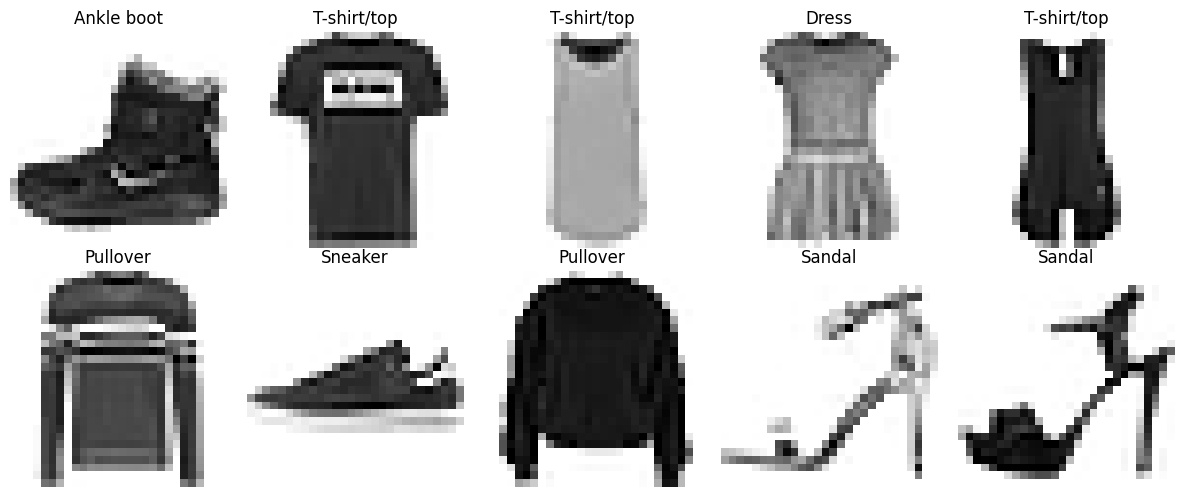

In [25]:
# 1. Chuẩn hóa dữ liệu (Đưa giá trị pixel từ về)
X_train, X_valid, X_test = X_train / 255.0, X_valid / 255.0, X_test / 255.0 #

# Kiểm tra lại kiểu dữ liệu và giá trị lớn nhất sau khi chuẩn hóa
print(f"Kiểu dữ liệu sau chuẩn hóa: {X_train.dtype}")
print(f"Giá trị pixel lớn nhất: {X_train.max()} và nhỏ nhất: {X_train.min()}\n")

# 2. Trực quan hóa dữ liệu
# Vẽ 10 hình ảnh đầu tiên trong tập huấn luyện
plt.figure(figsize=(12, 5))
for i in range(10):
    # Tạo một khung con (subplot) với lưới 2 hàng, 5 cột
    plt.subplot(2, 5, i + 1)

    # Hiển thị ảnh với thang độ xám (binary/grayscale)
    plt.imshow(X_train[i], cmap="binary") #

    # Lấy nhãn của ảnh và tra cứu tên lớp tương ứng
    plt.title(class_names[y_train[i]]) #

    # Ẩn trục tọa độ cho ảnh nhìn gọn gàng hơn
    plt.axis("off")

# Tự động căn chỉnh khoảng cách giữa các ảnh
plt.tight_layout()
plt.show()

### PHẦN 3.1: Mạng AlexNet - Cột mốc lịch sử & Khối trích xuất đặc trưng

> **1. Sự ra đời của AlexNet**
> AlexNet được phát triển bởi Alex Krizhevsky, Ilya Sutskever và Geoffrey Hinton, đã giành chiến thắng áp đảo trong cuộc thi ILSVRC 2012 khi giảm tỷ lệ lỗi top-5 xuống chỉ còn 17%, bỏ xa đối thủ thứ hai (26%). Kiến trúc này kế thừa mạng LeNet-5 cổ điển nhưng có quy mô lớn hơn, sâu hơn và là mạng đầu tiên xếp chồng trực tiếp các lớp tích chập lên nhau thay vì bắt buộc xen kẽ một lớp gộp (pooling) sau mỗi lớp tích chập.
>
> **2. Các kỹ thuật đột phá trong phần trích xuất đặc trưng**
> Khối trích xuất đặc trưng của AlexNet áp dụng những kỹ thuật mang tính bước ngoặt:
> *   **Hàm kích hoạt ReLU:** AlexNet sử dụng ReLU thay cho hàm Sigmoid hay Tanh truyền thống. Việc không bị bão hòa ở phần dương giúp tăng tốc độ hội tụ của thuật toán giảm độ dốc (gradient descent) lên rất nhiều lần.
> *   **Chuẩn hóa phản hồi cục bộ (Local Response Normalization - LRN):** AlexNet thêm một bước chuẩn hóa ngay sau bước ReLU của các lớp tích chập C1 và C3. Kỹ thuật này tạo ra sự kích hoạt cạnh tranh: các nơ-ron được kích hoạt mạnh nhất sẽ ức chế các nơ-ron khác nằm ở cùng vị trí trong các bản đồ đặc trưng lân cận, giúp các bản đồ đặc trưng chuyên biệt hóa và cải thiện khả năng tổng quát hóa.
>
> *Lưu ý thực hành: Tập dữ liệu gốc của AlexNet là ImageNet với ảnh màu kích thước $227 \times 227 \times 3$. Trong đoạn code dưới đây, chúng ta sẽ xây dựng phần trích xuất đặc trưng chuẩn lịch sử của AlexNet. Trong thực tế (ví dụ dùng cho Fashion MNIST $28 \times 28$), ảnh cần được phóng to (upsample) trước khi đưa vào mạng.*

In [26]:
# Khởi tạo mô hình Sequential cho AlexNet
alexnet_model = tf.keras.models.Sequential(name="AlexNet_Historical")

# --- KHỐI TRÍCH XUẤT ĐẶC TRƯNG (CONVOLUTIONAL BASE) ---

# Lớp C1: Tích chập đầu tiên với kernel lớn 11x11, stride 4 để giảm nhanh không gian
alexnet_model.add(tf.keras.layers.Conv2D(filters=96, kernel_size=(11,11), strides=4,
                                         padding='valid', activation='relu',
                                         input_shape=(227, 227, 3)))

# Bước chuẩn hóa LRN: Trong Keras, ta có thể dùng tf.nn.local_response_normalization bọc trong lớp Lambda
# Các siêu tham số gốc của AlexNet: r = 5, alpha = 0.0001, beta = 0.75, k = 2
alexnet_model.add(tf.keras.layers.Lambda(
    lambda x: tf.nn.local_response_normalization(x, depth_radius=2, alpha=0.0001, beta=0.75, bias=2.0)
))

# Lớp S2: Gộp cực đại (Max Pooling) với kernel 3x3, stride 2
alexnet_model.add(tf.keras.layers.MaxPool2D(pool_size=(3,3), strides=2, padding='valid'))

# Lớp C3: Tích chập 5x5, padding 'same' để giữ nguyên kích thước không gian
alexnet_model.add(tf.keras.layers.Conv2D(filters=256, kernel_size=(5,5), strides=1,
                                         padding='same', activation='relu'))
# Chuẩn hóa LRN lần 2
alexnet_model.add(tf.keras.layers.Lambda(
    lambda x: tf.nn.local_response_normalization(x, depth_radius=2, alpha=0.0001, beta=0.75, bias=2.0)
))

# Lớp S4: Gộp cực đại
alexnet_model.add(tf.keras.layers.MaxPool2D(pool_size=(3,3), strides=2, padding='valid'))

# Lớp C5, C6, C7: Các lớp tích chập 3x3 được xếp chồng trực tiếp lên nhau
alexnet_model.add(tf.keras.layers.Conv2D(filters=384, kernel_size=(3,3), strides=1, padding='same', activation='relu'))
alexnet_model.add(tf.keras.layers.Conv2D(filters=384, kernel_size=(3,3), strides=1, padding='same', activation='relu'))
alexnet_model.add(tf.keras.layers.Conv2D(filters=256, kernel_size=(3,3), strides=1, padding='same', activation='relu'))

# Lớp S8: Lớp gộp cực đại cuối cùng trước khi chuyển sang mạng kết nối đầy đủ
alexnet_model.add(tf.keras.layers.MaxPool2D(pool_size=(3,3), strides=2, padding='valid'))

print("Đã xây dựng xong Khối trích xuất đặc trưng của AlexNet!")

Đã xây dựng xong Khối trích xuất đặc trưng của AlexNet!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### PHẦN 3.2: Mạng AlexNet - Khối phân loại (Fully Connected) & Kỹ thuật Dropout

> **3. Khối Phân loại và Kỹ thuật Dropout**
> Sau khi đi qua hàng loạt các lớp tích chập và gộp, dữ liệu không gian 2D sẽ được "làm phẳng" (Flatten) thành một vector 1D để đưa vào các lớp kết nối đầy đủ (Fully Connected - FC), đóng vai trò như một bộ phân loại truyền thống.
>
> Kiến trúc AlexNet có 3 lớp kết nối đầy đủ ở cuối mạng. Trong đó, hai lớp đầu tiên (thường được gọi là F9 và F10, hoặc FC6 và FC7) có kích thước rất lớn với 4.096 nơ-ron mỗi lớp. Việc sử dụng số lượng tham số khổng lồ ở đây dẫn đến nguy cơ học vẹt (overfitting) rất cao.
>
> Để giải quyết vấn đề này, các tác giả đã áp dụng một kỹ thuật mang tính đột phá thời bấy giờ là **Dropout**:
> * Trong quá trình huấn luyện, tại mỗi bước, mạng sẽ ngẫu nhiên "tắt" (vô hiệu hóa) một tỷ lệ nơ-ron nhất định (ở đây là 50%) tại các lớp F9 và F10.
> * Điều này buộc các nơ-ron còn lại phải tự lực trích xuất các đặc trưng hữu ích thay vì quá phụ thuộc vào một vài nơ-ron lân cận (ngăn chặn sự đồng thích nghi - co-adaptation).
> * Kết quả là Dropout hoạt động như một bộ điều chuẩn (regularizer) cực kỳ mạnh mẽ, giúp mô hình tổng quát hóa tốt hơn trên dữ liệu mới.
>
> *Lưu ý: Lớp đầu ra gốc của AlexNet dùng để phân loại 1000 đối tượng của ImageNet. Tuy nhiên, để bạn có thể huấn luyện thử với tập dữ liệu Fashion MNIST đã tải ở Phần 2, chúng ta sẽ thiết lập lớp đầu ra là 10 nơ-ron tương ứng với 10 nhãn mặt hàng thời trang.*

### PHẦN 3.3: Huấn luyện và Đánh giá AlexNet trên Fashion MNIST

> **1. Thách thức về kích thước đầu vào**
> Kiến trúc AlexNet chúng ta vừa xây dựng yêu cầu đầu vào $(227, 227, 3)$. Trong khi đó, dữ liệu Fashion MNIST có kích thước $(28, 28)$ và chỉ có 1 kênh màu (grayscale). Để chạy được mô hình này, chúng ta có hai cách:
> * **Cách 1:** Thay đổi `input_shape` của lớp đầu tiên trong AlexNet (Lớp C1). Tuy nhiên, các bộ lọc $11 \times 11$ stride 4 sẽ làm biến mất dữ liệu quá nhanh trên ảnh $28 \times 28$.
> * **Cách 2:** Resize ảnh đầu vào lên $227 \times 227$. Đây là cách giúp giữ đúng cấu trúc lịch sử của mạng.
>
> **2. Tối ưu hóa quá trình huấn luyện**
> Vì AlexNet là một mạng lớn, việc huấn luyện toàn bộ 60,000 ảnh đã resize trên Colab có thể tốn nhiều thời gian. Trong đoạn mã dưới đây, chúng ta sẽ thực hiện các bước chuẩn bị dữ liệu tinh gọn để kiểm chứng kiến trúc.

In [27]:
import numpy as np

# Do AlexNet yêu cầu ảnh 3 kênh (RGB), ta cần thêm chiều cho dữ liệu Fashion MNIST
# và chuyển đổi từ (55000, 28, 28) thành (55000, 28, 28, 1)
X_train_expanded = np.expand_dims(X_train, axis=-1)
X_valid_expanded = np.expand_dims(X_valid, axis=-1)

# Định nghĩa một mô hình AlexNet thực tế hơn cho Fashion MNIST (đã tinh chỉnh input_shape)
# Nếu muốn dùng đúng 227x227, ta cần sử dụng tf.image.resize trong một lớp Lambda

alexnet_fmnist = tf.keras.models.Sequential([
    # Lớp Resize để khớp với kiến trúc AlexNet gốc mà không cần xử lý thủ công tập dữ liệu
    tf.keras.layers.Resizing(227, 227, input_shape=(28, 28, 1)),

    # Khối trích xuất đặc trưng (như đã định nghĩa ở phần 3.1)
    tf.keras.layers.Conv2D(filters=96, kernel_size=(11,11), strides=4, activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(3,3), strides=2),

    tf.keras.layers.Conv2D(filters=256, kernel_size=(5,5), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(3,3), strides=2),

    tf.keras.layers.Conv2D(filters=384, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(filters=384, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(3,3), strides=2),

    # Khối phân loại (như đã định nghĩa ở phần 3.2)
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Biên dịch
alexnet_fmnist.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

print("Mô hình AlexNet thích ứng với Fashion MNIST đã sẵn sàng!")
# Lưu ý: Việc huấn luyện thực tế với Resize 227x227 tốn rất nhiều RAM GPU.
# Bạn có thể thử huấn luyện với batch_size nhỏ (ví dụ 32).
# history = alexnet_fmnist.fit(X_train_expanded[:1000], y_train[:1000], epochs=1, validation_split=0.2)

Mô hình AlexNet thích ứng với Fashion MNIST đã sẵn sàng!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
# --- KHỐI PHÂN LOẠI (FULLY CONNECTED CLASSIFIER) ---

# Làm phẳng (Flatten) bản đồ đặc trưng đầu ra của lớp S8 thành vector 1D
alexnet_model.add(tf.keras.layers.Flatten())

# Lớp F9 (hoặc FC6): Lớp kết nối đầy đủ với 4096 nơ-ron và hàm kích hoạt ReLU
alexnet_model.add(tf.keras.layers.Dense(units=4096, activation='relu'))
# Áp dụng kỹ thuật Dropout với tỷ lệ 50% (0.5) trong quá trình huấn luyện
alexnet_model.add(tf.keras.layers.Dropout(rate=0.5))

# Lớp F10 (hoặc FC7): Lớp kết nối đầy đủ thứ hai với 4096 nơ-ron
alexnet_model.add(tf.keras.layers.Dense(units=4096, activation='relu'))
# Tiếp tục áp dụng Dropout 50%
alexnet_model.add(tf.keras.layers.Dropout(rate=0.5))

# Lớp Đầu ra (Output Layer):
# Sử dụng 10 nơ-ron (cho Fashion MNIST) cùng hàm Softmax để xuất ra xác suất của từng lớp
alexnet_model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

# Biên dịch mô hình sơ bộ (Compile)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
alexnet_model.compile(loss='sparse_categorical_crossentropy',
                      optimizer=optimizer,
                      metrics=['accuracy'])

# In ra bảng tóm tắt kiến trúc của toàn bộ mạng AlexNet
print("--- TÓM TẮT KIẾN TRÚC MẠNG ALEXNET ---")
alexnet_model.summary()

--- TÓM TẮT KIẾN TRÚC MẠNG ALEXNET ---


Model: "AlexNet_Historical"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_78 (Conv2D)              │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 55, 55, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 27, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,322,314 (222.48 MB)

 Trainable params: 58,322,314 (222.48 MB)

 Non-trainable params: 0 (0.00 B)

### PHẦN 3.4: Trực quan hóa bản đồ đặc trưng (Feature Map Visualization)

> Một trong những cách tốt nhất để hiểu cách hoạt động của CNN là quan sát đầu ra của các lớp trung gian. Mỗi bộ lọc (filter) trong lớp tích chập sẽ học cách phát hiện một đặc trưng nhất định (như đường kẻ, góc cạnh ở các lớp đầu, và các hình khối phức tạp ở các lớp sau).
>
> Trong phần này, chúng ta sẽ:
> 1. Tạo một mô hình con (Sub-model) lấy đầu vào từ ảnh và trích xuất đầu ra từ các lớp `Conv2D` đầu tiên.
> 2. Đưa một ảnh mẫu từ tập Fashion MNIST qua mô hình này.
> 3. Hiển thị các bản đồ đặc trưng để quan sát cách mạng nơ-ron biến đổi dữ liệu hình ảnh gốc.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step
Kích thước bản đồ đặc trưng lớp C1: (1, 55, 55, 96)


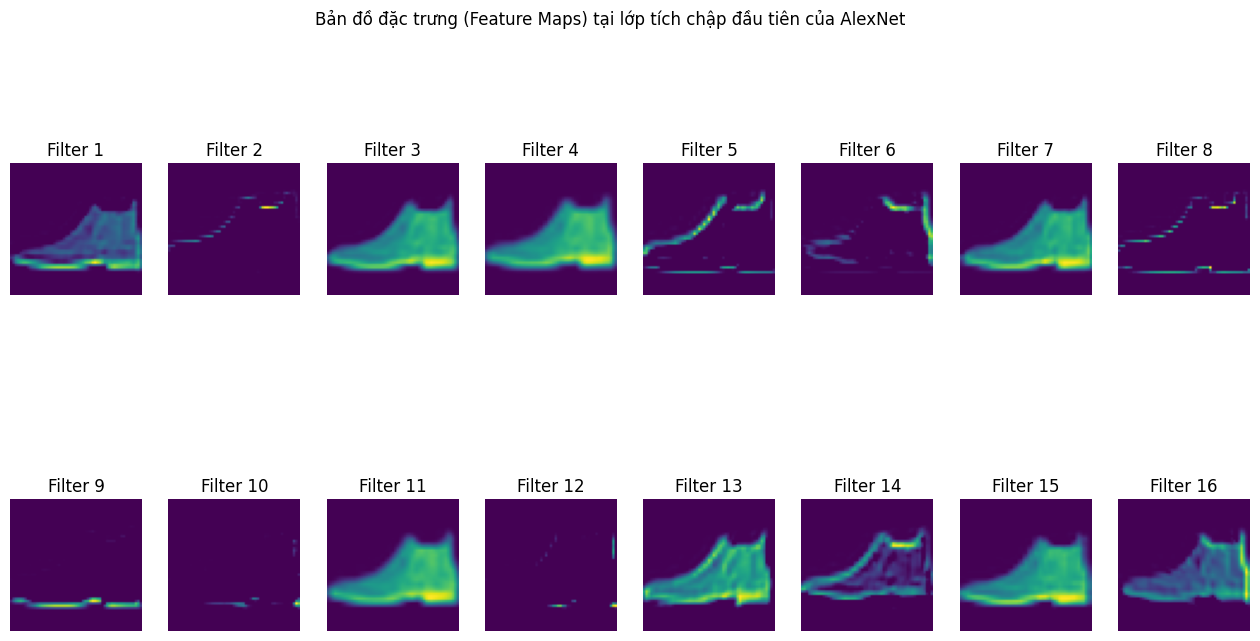

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Chọn một hình ảnh mẫu và đảm bảo có đủ 4 chiều (batch, h, w, channels)
# X_test hiện tại là (10000, 28, 28), cần thành (1, 28, 28, 1)
sample_image = np.expand_dims(X_test[0:1], axis=-1)

# Đảm bảo mô hình đã được xây dựng và 'gọi' với input cụ thể
alexnet_fmnist.build(input_shape=(None, 28, 28, 1))
_ = alexnet_fmnist(sample_image)

# 2. Trích xuất các lớp Conv2D
# Chúng ta truy cập vào các tensor đầu ra của từng lớp cụ thể
layer_outputs = [layer.output for layer in alexnet_fmnist.layers if isinstance(layer, tf.keras.layers.Conv2D)]

# Khởi tạo mô hình trích xuất
# Sử dụng layer đầu tiên của Sequential làm input tensor thực tế
activation_model = tf.keras.models.Model(inputs=alexnet_fmnist.layers[0].input, outputs=layer_outputs[:2])

# 3. Dự đoán
activations = activation_model.predict(sample_image)

# 4. Trực quan hóa
first_layer_activation = activations[0]
print(f"Kích thước bản đồ đặc trưng lớp C1: {first_layer_activation.shape}")

plt.figure(figsize=(16, 8))
for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Filter {i+1}')

plt.suptitle("Bản đồ đặc trưng (Feature Maps) tại lớp tích chập đầu tiên của AlexNet")
plt.show()

### PHẦN 3.5: Tổng kết về AlexNet - Di sản và Hạn chế

> **1. Những đóng góp mang tính bước ngoặt:**
> *   **Chứng minh sức mạnh của Deep Learning:** AlexNet là minh chứng thực tế đầu tiên cho thấy các mạng nơ-ron sâu (Deep Neural Networks) kết hợp với GPU có thể vượt xa các phương pháp Thị giác máy tính truyền thống.
> *   **Phổ biến hàm ReLU:** Thay thế Sigmoid bằng ReLU đã giải quyết vấn đề triệt tiêu đạo hàm và tăng tốc độ huấn luyện lên nhiều lần.
> *   **Kỹ thuật Dropout:** Đưa ra một giải pháp hiệu quả để kiểm soát quá khớp (overfitting) cho các mạng có hàng chục triệu tham số.
>
> **2. Hạn chế so với các mạng hiện đại:**
> *   **Kích thước bộ lọc lớn:** Việc dùng kernel $11 \times 11$ và $5 \times 5$ ở các lớp đầu gây tốn kém tính toán và làm mất mát nhiều chi tiết nhỏ (fine-grained details).
> *   **Tham số tập trung ở các lớp FC:** Phần lớn trong số ~60 triệu tham số của AlexNet nằm ở 3 lớp Dense cuối cùng, khiến mô hình nặng nề nhưng chưa tối ưu về khả năng trích xuất đặc trưng.
> *   **Độ sâu hạn chế:** Với chỉ 8 lớp, AlexNet chưa đủ khả năng nắm bắt các đặc trưng cực kỳ trừu tượng như các mạng ResNet (hàng trăm lớp) sau này.
>
> *Trong các phần tiếp theo, chúng ta sẽ tìm hiểu cách VGGNet và GoogLeNet giải quyết những hạn chế này bằng cách sử dụng các bộ lọc nhỏ hơn và cấu trúc dạng khối thông minh hơn.*

### PHẦN 4.1: Mạng VGG16 - Sức mạnh của sự đơn giản và Cấu trúc dạng khối

> **1. Sự ra đời và Triết lý thiết kế của VGGNet**
> VGGNet được phát triển bởi Karen Simonyan và Andrew Zisserman (thuộc Nhóm VGG, Đại học Oxford) và là Á quân của thử thách ILSVRC 2014. Trái ngược với các kiến trúc phức tạp, VGG nổi bật với triết lý thiết kế **cổ điển, cực kỳ đơn giản và mạch thẳng**.
>
> Thay vì sử dụng các bộ lọc lớn như $11 \times 11$ hay $5 \times 5$ của AlexNet, VGG16 tạo ra bước ngoặt khi **đồng nhất sử dụng các bộ lọc (kernel) kích thước siêu nhỏ $3 \times 3$** trong toàn bộ mạng.
>
> **2. Tại sao lại là bộ lọc $3 \times 3$?**
> Việc xếp chồng các bộ lọc nhỏ mang lại sức mạnh to lớn:
> * **Tối ưu Vùng cảm nhận (Receptive Field):** Xếp chồng 2 lớp $3 \times 3$ sẽ tạo ra vùng cảm nhận tương đương với 1 lớp $5 \times 5$; và xếp chồng 3 lớp $3 \times 3$ sẽ tương đương với 1 lớp $7 \times 7$.
> * **Tăng tính phi tuyến:** Thay vì 1 lớp $7 \times 7$ chỉ có 1 hàm kích hoạt, việc dùng 3 lớp $3 \times 3$ cho phép chèn 3 hàm ReLU. Điều này giúp mạng học được các biểu diễn phức tạp và có tính phân biệt cao hơn.
> * **Giảm tham số:** Số lượng trọng số cần huấn luyện của 3 lớp $3 \times 3$ ($3 \times 3^2 = 27$) ít hơn đáng kể so với 1 lớp $7 \times 7$ ($7^2 = 49$).
>
> **3. Cấu trúc dạng khối (Blocks)**
> VGG16 có tổng cộng 16 lớp có trọng số (13 lớp Convolutional + 3 lớp Fully Connected). Phần trích xuất đặc trưng được chia làm **5 khối**. Kết thúc mỗi khối luôn là một lớp Max Pooling $2 \times 2$ (stride 2) để giảm một nửa không gian. Đồng thời, số lượng kênh (filters) sẽ được **nhân đôi** sau mỗi lớp gộp: $64 \rightarrow 128 \rightarrow 256 \rightarrow 512 \rightarrow 512$.

In [32]:
# Để hiểu rõ cấu trúc của VGG16, chúng ta sẽ tự tay xây dựng 2 khối (blocks) đầu tiên
# sử dụng Keras Sequential API theo đúng tỷ lệ của bản gốc.

vgg_demo = tf.keras.models.Sequential(name="VGG16_Demo_Blocks")

# --- KHỐI 1 (Block 1) ---
# Gồm 2 lớp Tích chập 3x3 (64 bộ lọc) và 1 lớp Gộp cực đại
# Lưu ý: padding='same' giúp duy trì kích thước ảnh sau khi tích chập
vgg_demo.add(tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same',
                                    activation='relu', input_shape=(224, 224, 3), name='block1_conv1'))
vgg_demo.add(tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same',
                                    activation='relu', name='block1_conv2'))
vgg_demo.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2), name='block1_pool'))

# --- KHỐI 2 (Block 2) ---
# Gồm 2 lớp Tích chập 3x3 (số lượng bộ lọc nhân đôi lên 128) và 1 lớp Gộp cực đại
vgg_demo.add(tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), padding='same',
                                    activation='relu', name='block2_conv1'))
vgg_demo.add(tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), padding='same',
                                    activation='relu', name='block2_conv2'))
vgg_demo.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2), name='block2_pool'))

# In ra tóm tắt để quan sát sự thay đổi của Kích thước không gian và Số lượng kênh
print("--- CẤU TRÚC 2 KHỐI ĐẦU TIÊN CỦA VGG16 ---")
vgg_demo.summary()

--- CẤU TRÚC 2 KHỐI ĐẦU TIÊN CỦA VGG16 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "VGG16_Demo_Blocks"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,160 (1016.25 KB)

 Trainable params: 260,160 (1016.25 KB)

 Non-trainable params: 0 (0.00 B)

### PHẦN 4.2: Mạng VGG16 - Kế thừa tri thức với Keras Applications (Pre-trained Model)

> **1. Thách thức của VGG16 và Giải pháp**
> Mặc dù VGG16 có cấu trúc đơn giản, nó lại sở hữu một khối lượng tham số khổng lồ (lên tới khoảng **138 triệu tham số**), đòi hỏi tới hàng tỷ phép toán cho mỗi lần dự đoán. Việc huấn luyện một mạng sâu như vậy từ con số 0 (from scratch) vô cùng tốn kém và cực kỳ dễ dẫn đến quá khớp (overfitting) nếu tập dữ liệu của bạn nhỏ.
>
> Tuy nhiên, các đặc trưng do VGG16 trích xuất lại có tính ổn định và tính phân biệt cực kỳ xuất sắc. Giải pháp hoàn hảo ở đây là áp dụng **Học chuyển giao (Transfer Learning)**: Kế thừa bộ trọng số đã được huấn luyện sẵn (Pre-trained) trên tập dữ liệu khổng lồ ImageNet.
>
> **2. Triển khai VGG16 làm Mạng xương sống (Backbone)**
> Keras cung cấp sẵn mô hình VGG16 trong module `tf.keras.applications`, cho phép bạn tải mạng này làm "bộ trích xuất đặc trưng" chỉ với một dòng code. Để làm điều này, ta cần:
> *   `weights='imagenet'`: Tải bộ trọng số chuẩn đã được tối ưu hóa.
> *   `include_top=False`: **Cắt bỏ phần đầu** (bỏ qua các lớp Fully Connected ở đỉnh mạng vốn dùng để phân loại 1.000 lớp đối tượng của ImageNet). Ta chỉ giữ lại phần thân trích xuất đặc trưng.

In [33]:
# Tải mô hình cơ sở VGG16 (Base Model) từ Keras Applications
# Lưu ý: Cần resize ảnh (ví dụ 224x224) nếu muốn sử dụng kiến trúc chuẩn
vgg16_base = tf.keras.applications.VGG16(
    weights='imagenet',        # Sử dụng trọng số đã huấn luyện trên ImageNet
    include_top=False,         # Cắt bỏ phần đầu (Fully Connected Layers)
    input_shape=(224, 224, 3)  # Kích thước đầu vào chuẩn của VGG16
)

# In ra tóm tắt kiến trúc của mạng cơ sở VGG16
print("--- TÓM TẮT MẠNG XƯƠNG SỐNG (BACKBONE) VGG16 ---")
vgg16_base.summary()

# In thêm thông tin để kiểm tra
print(f"\nTổng số lớp trong VGG16 Base (chưa bao gồm Head mới): {len(vgg16_base.layers)}")

--- TÓM TẮT MẠNG XƯƠNG SỐNG (BACKBONE) VGG16 ---


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)


Tổng số lớp trong VGG16 Base (chưa bao gồm Head mới): 19


### PHẦN 4.3: VGG16 - Xây dựng Bộ phân loại tùy chỉnh (Custom Head)

> Sau khi đã cắt bỏ phần đầu của VGG16 (`include_top=False`), chúng ta nhận được đầu ra là các bản đồ đặc trưng 3D. Để chuyển đổi chúng thành dự đoán phân loại, chúng ta cần thực hiện các bước sau:
>
> 1. **Lớp nén không gian:** Sử dụng `GlobalAveragePooling2D` để tính trung bình mỗi bản đồ đặc trưng, giúp giảm mạnh số lượng tham số so với lớp `Flatten` truyền thống.
> 2. **Lớp ẩn (Dense Layer):** Thêm một hoặc nhiều lớp kết nối đầy đủ để học các tổ hợp đặc trưng phức tạp.
> 3. **Lớp đầu ra (Output Layer):** Sử dụng hàm `softmax` với số lượng nơ-ron khớp với số lớp của bài toán (ví dụ: 10 lớp cho Fashion MNIST).

In [34]:
# 1. Đóng băng các lớp của VGG16 để không huấn luyện lại chúng (Học chuyển giao)
vgg16_base.trainable = False

# 2. Xây dựng mô hình hoàn chỉnh
vgg_model = tf.keras.models.Sequential([
    # Sử dụng lại base model đã tải ở phần 4.2
    vgg16_base,

    # Thêm bộ phân loại mới
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
], name="VGG16_FashionMNIST_Transfer")

# 3. Biên dịch mô hình
vgg_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("--- KIẾN TRÚC MÔ HÌNH VGG16 HOÀN CHỈNH ---")
vgg_model.summary()

--- KIẾN TRÚC MÔ HÌNH VGG16 HOÀN CHỈNH ---


Model: "VGG16_FashionMNIST_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### PHẦN 5.1: GoogLeNet và Đột phá mở rộng chiều ngang (Inception Module)

> **1. Sự ra đời của GoogLeNet**
> GoogLeNet (hay Inception-v1) được phát triển bởi nhóm nghiên cứu tại Google và đã giành chiến thắng tại thử thách ILSVRC 2014 với tỷ lệ lỗi top-5 dưới 7%. Điều đáng kinh ngạc là dù sâu hơn rất nhiều, GoogLeNet lại sử dụng tham số cực kỳ hiệu quả: mạng chỉ có khoảng 6 triệu tham số, ít hơn 10 lần so với AlexNet (~60 triệu).
>
> **2. Mô-đun Inception: Đột phá mở rộng chiều ngang**
> Thay vì cố gắng tìm ra kích thước bộ lọc tối ưu nhất (như VGG chỉ dùng $3 \times 3$), GoogLeNet áp dụng triết lý "dùng tất cả". Một mô-đun Inception tiêu chuẩn chia tín hiệu đầu vào thành 4 nhánh song song:
> *   Nhánh 1: Tích chập $1 \times 1$
> *   Nhánh 2: Tích chập $3 \times 3$
> *   Nhánh 3: Tích chập $5 \times 5$
> *   Nhánh 4: Gộp cực đại (Max Pooling) $3 \times 3$
>
> Việc sử dụng đa dạng kích thước kernel giúp mạng **nắm bắt các mẫu (patterns) ở nhiều tỷ lệ khác nhau** tại cùng một cấp độ. Các bản đồ đặc trưng từ 4 nhánh sau đó được nối (concatenate) lại với nhau dọc theo chiều sâu. Tất cả các lớp này đều dùng stride = 1 và padding = "same" để đảm bảo đầu ra có cùng kích thước không gian.
>
> **3. "Phép thuật" của Tích chập $1 \times 1$**
> Nếu chạy trực tiếp các bộ lọc $3 \times 3$ và $5 \times 5$, chi phí tính toán sẽ bùng nổ. Để giải quyết, GoogLeNet chèn các lớp tích chập $1 \times 1$ vào trước chúng nhằm 3 mục đích cốt lõi:
> *   **Lớp thắt cổ chai (Bottleneck):** Giảm số lượng bản đồ đặc trưng (giảm chiều), từ đó cắt giảm mạnh chi phí tính toán và số lượng tham số.
> *   **Nắm bắt đặc trưng chiều sâu:** Chụp lại các mẫu phân bố xuyên kênh (cross-channels) thay vì các đặc trưng không gian.
> *   **Tăng tính phi tuyến:** Hoạt động như một mạng nơ-ron hai lớp quét qua hình ảnh, tăng cường sức mạnh biểu diễn.

In [35]:
# Để thiết kế mô-đun Inception phức tạp với các nhánh song song,
# chúng ta KHÔNG THỂ dùng Sequential API, mà phải dùng Keras Functional API.

def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3, filters_5x5_reduce, filters_5x5, filters_pool):
    """
    Hàm tạo ra một khối Inception tiêu chuẩn (có sử dụng 1x1 bottleneck).
    """
    # Nhánh 1: Chỉ dùng Tích chập 1x1
    branch1 = tf.keras.layers.Conv2D(filters_1x1, (1,1), padding='same', activation='relu')(x)

    # Nhánh 2: Tích chập 1x1 (giảm chiều) -> Tích chập 3x3
    branch2 = tf.keras.layers.Conv2D(filters_3x3_reduce, (1,1), padding='same', activation='relu')(x)
    branch2 = tf.keras.layers.Conv2D(filters_3x3, (3,3), padding='same', activation='relu')(branch2)

    # Nhánh 3: Tích chập 1x1 (giảm chiều) -> Tích chập 5x5
    branch3 = tf.keras.layers.Conv2D(filters_5x5_reduce, (1,1), padding='same', activation='relu')(x)
    branch3 = tf.keras.layers.Conv2D(filters_5x5, (5,5), padding='same', activation='relu')(branch3)

    # Nhánh 4: Max Pooling 3x3 -> Tích chập 1x1 (giảm chiều)
    branch4 = tf.keras.layers.MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    branch4 = tf.keras.layers.Conv2D(filters_pool, (1,1), padding='same', activation='relu')(branch4)

    # Nối (Concatenate) cả 4 nhánh lại với nhau dọc theo trục kênh (axis=-1)
    output = tf.keras.layers.concatenate([branch1, branch2, branch3, branch4], axis=-1)

    return output

# --- TEST THỬ MÔ-ĐUN INCEPTION ---
# Giả sử đầu vào là một bản đồ đặc trưng có kích thước 28x28 và sâu 192 kênh
inputs = tf.keras.layers.Input(shape=(28, 28, 192))

# Tạo một khối Inception (tham số tương đương với module Inception đầu tiên trong GoogLeNet gốc)
inception_out = inception_module(inputs,
                                 filters_1x1=64,
                                 filters_3x3_reduce=96, filters_3x3=128,
                                 filters_5x5_reduce=16, filters_5x5=32,
                                 filters_pool=32)

# Tạo một Model tạm thời chỉ để in ra bảng tóm tắt
demo_inception_model = tf.keras.Model(inputs=inputs, outputs=inception_out, name="Inception_Module_Demo")

print("--- TÓM TẮT MÔ-ĐUN INCEPTION ---")
demo_inception_model.summary()

--- TÓM TẮT MÔ-ĐUN INCEPTION ---


Model: "Inception_Module_Demo"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 28, 28,    │          0 │ -                 │
│ (InputLayer)        │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_89 (Conv2D)  │ (None, 28, 28,    │     18,528 │ input_layer_19[0… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_91 (Conv2D)  │ (None, 28, 28,    │      3,088 │ input_layer_19[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_19    │ (None, 28, 28,    │          0 │ input_layer_19[0… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_88 (Conv2D)  │ (None, 28, 28,    │     12,352 │ input_layer_19[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_90 (Conv2D)  │ (None, 28, 28,    │    110,720 │ conv2d_89[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_92 (Conv2D)  │ (None, 28, 28,    │     12,832 │ conv2d_91[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_93 (Conv2D)  │ (None, 28, 28,    │      6,176 │ max_pooling2d_19… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 28, 28,    │          0 │ conv2d_88[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_90[0][0],  │
│                     │                   │            │ conv2d_92[0][0],  │
│                     │                   │            │ conv2d_93[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 163,696 (639.44 KB)

 Trainable params: 163,696 (639.44 KB)

 Non-trainable params: 0 (0.00 B)

### PHẦN 5.2: Hoàn thiện GoogLeNet - Global Average Pooling và Bộ phân loại phụ

> **1. Kiến trúc tổng thể của GoogLeNet**
> Xương sống của GoogLeNet là một ngăn xếp cực sâu bao gồm **9 mô-đun Inception** được xếp chồng lên nhau, xen kẽ với các lớp gộp cực đại (Max Pooling) để giảm độ phân giải không gian của ảnh và tăng tốc độ tính toán. Mặc dù rất sâu, nhưng nhờ các lớp thắt cổ chai $1 \times 1$, GoogLeNet chỉ có khoảng 6 triệu tham số (ít hơn 10 lần so với AlexNet).
>
> **2. Vũ khí bí mật: Global Average Pooling (GAP)**
> Khác với AlexNet hay VGG sử dụng các lớp kết nối đầy đủ (Fully Connected/Dense) khổng lồ ở cuối mạng gây tốn hàng chục triệu tham số, GoogLeNet áp dụng một kỹ thuật mang tính bước ngoặt: **Lớp gộp trung bình toàn cục (Global Average Pooling)**.
> Thay vì làm phẳng (Flatten) bản đồ đặc trưng, GAP tính giá trị trung bình của *toàn bộ* mỗi bản đồ đặc trưng. Lớp này loại bỏ hoàn toàn thông tin không gian nhưng giúp giảm triệt để số lượng tham số, hạn chế rủi ro quá khớp (overfitting) và khiến mạng cực kỳ nhẹ.
>
> **3. Bộ phân loại phụ (Auxiliary Classifiers)**
> Đối với một mạng quá sâu, gradient khi truyền ngược (backpropagation) từ cuối mạng về đầu mạng có thể bị suy giảm và biến mất (triệt tiêu đạo hàm). Để chống lại hiện tượng này, GoogLeNet cắm thêm hai **Bộ phân loại phụ** ở phần giữa của mạng (đỉnh của mô-đun Inception thứ 3 và thứ 6). Trong quá trình huấn luyện, tổn thất (loss) từ các bộ phân loại phụ này sẽ được cộng vào tổn thất tổng thể để hỗ trợ cập nhật trọng số và đóng vai trò như một cơ chế điều chuẩn (regularization).

In [36]:
# Để minh họa, chúng ta sẽ xây dựng một phiên bản GoogLeNet thu gọn
# (sử dụng lại hàm inception_module đã định nghĩa ở Phần 5.1)

inputs = tf.keras.layers.Input(shape=(224, 224, 3))

# --- 1. PHẦN GỐC (STEM) ---
x = tf.keras.layers.Conv2D(64, (7,7), strides=2, padding='same', activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D((3,3), strides=2, padding='same')(x)
x = tf.keras.layers.Conv2D(192, (3,3), strides=1, padding='same', activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((3,3), strides=2, padding='same')(x)

# --- 2. NGĂN XẾP INCEPTION (Minh họa 2 module thay vì 9 module như bản gốc) ---
# Inception 3a
x = inception_module(x, filters_1x1=64,
                     filters_3x3_reduce=96, filters_3x3=128,
                     filters_5x5_reduce=16, filters_5x5=32,
                     filters_pool=32)
# Inception 3b
x = inception_module(x, filters_1x1=128,
                     filters_3x3_reduce=128, filters_3x3=192,
                     filters_5x5_reduce=32, filters_5x5=96,
                     filters_pool=64)

# (Tùy chọn) Cắm một BỘ PHÂN LOẠI PHỤ (Auxiliary Classifier) vào giữa mạng
aux_x = tf.keras.layers.AveragePooling2D((5,5), strides=3)(x)
aux_x = tf.keras.layers.Conv2D(128, (1,1), padding='same', activation='relu')(aux_x)
aux_x = tf.keras.layers.Flatten()(aux_x)
aux_x = tf.keras.layers.Dense(1024, activation='relu')(aux_x)
aux_output = tf.keras.layers.Dense(10, activation='softmax', name='aux_output')(aux_x) # 10 lớp phân loại

# Tiếp tục mạng chính (giảm chiều)
x = tf.keras.layers.MaxPooling2D((3,3), strides=2, padding='same')(x)

# --- 3. GLOBAL AVERAGE POOLING (Thay thế Fully Connected khổng lồ) ---
# GAP tính trung bình không gian của từng kênh, chuyển bản đồ đặc trưng (ví dụ 7x7x1024) thành vector (1024)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x) # Dropout 40% như bản gốc GoogLeNet

# --- 4. LỚP ĐẦU RA CHÍNH ---
main_output = tf.keras.layers.Dense(10, activation='softmax', name='main_output')(x)

# Khởi tạo mô hình với nhiều đầu ra (Multiple Outputs)
googlenet_demo = tf.keras.Model(inputs=inputs, outputs=[main_output, aux_output], name="GoogLeNet_Mini")

print("--- TÓM TẮT KIẾN TRÚC GOOGLENET (BẢN RÚT GỌN) ---")
googlenet_demo.summary()

--- TÓM TẮT KIẾN TRÚC GOOGLENET (BẢN RÚT GỌN) ---


Model: "GoogLeNet_Mini"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 112, 112,  │      9,472 │ input_layer_20[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 56, 56,    │          0 │ conv2d_94[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 56, 56,    │    110,784 │ max_pooling2d_20… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 28, 28,    │          0 │ conv2d_95[0][0]   │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 28, 28,    │     18,528 │ max_pooling2d_21… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_99 (Conv2D)  │ (None, 28, 28,    │      3,088 │ max_pooling2d_21… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 28, 28,    │          0 │ max_pooling2d_21… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 28, 28,    │     12,352 │ max_pooling2d_21… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 28, 28,    │    110,720 │ conv2d_97[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_100 (Conv2D) │ (None, 28, 28,    │     12,832 │ conv2d_99[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_101 (Conv2D) │ (None, 28, 28,    │      6,176 │ max_pooling2d_22… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 28, 28,    │          0 │ conv2d_96[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_98[0][0],  │
│                     │                   │            │ conv2d_100[0][0], │
│                     │                   │            │ conv2d_101[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_103 (Conv2D) │ (None, 28, 28,    │     32,896 │ concatenate_4[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_105 (Conv2D) │ (None, 28, 28,    │      8,224 │ concatenate_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_23    │ (None, 28, 28,    │          0 │ concatenate_4[0]… │
│ (MaxPooling2D)      │ 256)              │            │                 

 Total params: 9,138,948 (34.86 MB)

 Trainable params: 9,138,948 (34.86 MB)

 Non-trainable params: 0 (0.00 B)

### PHẦN 5.3: Kiểm chứng kiến trúc GoogLeNet đa đầu ra (Architecture Testing)

> Một điểm đặc trưng của GoogLeNet (Inception-v1) là sự hiện diện của các **Bộ phân loại phụ (Auxiliary Classifiers)**. Trong quá trình huấn luyện, mô hình sẽ trả về đồng thời hai giá trị tổn thất (loss).
>
> Để đảm bảo mô hình `googlenet_demo` hoạt động đúng như thiết kế, chúng ta sẽ:
> 1. Tạo một mảng dữ liệu giả lập (dummy data) có kích thước chuẩn $(224, 224, 3)$.
> 2. Đưa mảng này qua mô hình để thực hiện lệnh `predict`.
> 3. Kiểm tra cấu trúc của đầu ra để xác nhận sự tồn tại của cả `main_output` và `aux_output`.

In [37]:
# 1. Tạo dữ liệu giả lập (1 ảnh nhiễu ngẫu nhiên kích thước 224x224x3)
dummy_input = tf.random.uniform((1, 224, 224, 3))

# 2. Thực hiện dự đoán (Forward Pass)
outputs = googlenet_demo.predict(dummy_input)

# 3. Phân tích kết quả đầu ra
print(f"Số lượng đầu ra của mô hình: {len(outputs)}")

main_pred = outputs[0]
aux_pred = outputs[1]

print(f"\nKích thước đầu ra CHÍNH (main_output): {main_pred.shape} -> Khớp với 10 lớp")
print(f"Kích thước đầu ra PHỤ (aux_output):  {aux_pred.shape} -> Khớp với 10 lớp")

# Kiểm tra tổng xác suất của một đầu ra (phải xấp xỉ 1 do dùng Softmax)
print(f"\nTổng xác suất đầu ra chính: {np.sum(main_pred):.2f}")
print("Kiểm chứng hoàn tất! Mô hình đã sẵn sàng cho các bài toán phân loại phức tạp.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Số lượng đầu ra của mô hình: 2

Kích thước đầu ra CHÍNH (main_output): (1, 10) -> Khớp với 10 lớp
Kích thước đầu ra PHỤ (aux_output):  (1, 10) -> Khớp với 10 lớp

Tổng xác suất đầu ra chính: 1.00
Kiểm chứng hoàn tất! Mô hình đã sẵn sàng cho các bài toán phân loại phức tạp.


### PHẦN 6.1: Đột phá chiều sâu với Mạng ResNet - Học thặng dư và Khối Residual Unit

> **1. Rào cản của mạng học sâu: Triệt tiêu đạo hàm**
> Khi các mạng nơ-ron trở nên quá sâu (ví dụ hàng chục hay hàng trăm lớp), chúng gặp phải một rào cản tối ưu hóa nghiêm trọng gọi là hiện tượng **Triệt tiêu đạo hàm (Vanishing Gradients)**. Trong quá trình lan truyền ngược (backpropagation), tín hiệu gradient khi truyền về các lớp đầu tiên bị suy giảm đến mức gần như biến mất, khiến trọng số không được cập nhật và mạng ngừng học. Điều này khiến một mạng sâu truyền thống thậm chí còn hoạt động kém hơn một mạng nông.
>
> **2. Giải pháp của ResNet: Kết nối tắt (Skip Connections) và Học thặng dư**
> Kaiming He và cộng sự đã giải quyết triệt để rào cản này và vô địch ILSVRC 2015 với kiến trúc **ResNet (Mạng Thặng dư)** có độ sâu lên tới 152 lớp với sai số top-5 dưới 3.6%. Vũ khí bí mật của ResNet chính là các **Kết nối tắt (Skip Connections hay Shortcut Connections)**.
>
> Thay vì ép mạng học trực tiếp hàm mục tiêu phức tạp $h(x)$, kết nối tắt sẽ cộng thẳng tín hiệu đầu vào $x$ vào đầu ra của một lớp cao hơn. Lúc này, mạng bị ép học **hàm thặng dư (residual learning)** $f(x) = h(x) - x$. Nhờ đường kết nối tắt, tín hiệu gradient có một "đường cao tốc" để truyền thẳng qua hàng trăm lớp phi tuyến tính mà không bị suy giảm, giúp quá trình huấn luyện được tăng tốc đáng kể.
>
> **3. Cấu tạo Đơn vị Thặng dư (Residual Unit - RU)**
> ResNet bản chất là một ngăn xếp rất sâu của các Khối thặng dư. Một khối RU cơ bản (ví dụ trong ResNet-34) gồm hai lớp tích chập $3 \times 3$, kết hợp với Chuẩn hóa theo lô (Batch Normalization) và hàm kích hoạt ReLU, không sử dụng lớp gộp (pooling).
>
> Tuy nhiên, có một vấn đề xảy ra: đôi khi số lượng bản đồ đặc trưng tăng gấp đôi và kích thước không gian giảm một nửa (do sử dụng stride = 2), khiến nhánh đầu vào không khớp kích thước với đầu ra. Để có thể cộng trực tiếp chúng lại, nhánh kết nối tắt sẽ được chèn thêm một lớp tích chập $1 \times 1$ có stride = 2 nhằm ép kích thước đầu vào khớp hoàn toàn với đầu ra.


In [38]:
from functools import partial

# 1. Tạo một hàm Conv2D tùy chỉnh (DefaultConv2D) để giảm lặp lại code
# ResNet đồng nhất dùng bộ lọc 3x3, padding 'same', khởi tạo He và bỏ bias (do đã dùng BatchNorm)
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="same", kernel_initializer="he_normal", use_bias=False) #

# 2. Định nghĩa Khối Thặng dư (Residual Unit) bằng Keras Subclassing API
class ResidualUnit(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)

        # Đường chính (Main Path): Gồm 2 lớp Conv2D xen kẽ Batch Normalization và ReLU
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            tf.keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            tf.keras.layers.BatchNormalization()
        ] #

        # Đường tắt (Skip Connection): Xử lý sai lệch kích thước nếu strides > 1
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ] #

    def call(self, inputs):
        Z = inputs
        # Cho dữ liệu đi qua nhánh chính
        for layer in self.main_layers:
            Z = layer(Z)

        # Cho dữ liệu đi qua nhánh tắt
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)

        # Cộng gộp tín hiệu 2 nhánh (Residual Learning) và đưa qua hàm kích hoạt cuối
        return self.activation(Z + skip_Z) #

print("Đã khởi tạo thành công lớp ResidualUnit!")

Đã khởi tạo thành công lớp ResidualUnit!


### PHẦN 6.2: Đột phá chiều sâu với Mạng ResNet - Hoàn thiện kiến trúc ResNet-34

> **1. Xây dựng ngăn xếp ResNet-34 hoàn chỉnh**
> ResNet-34 là một mạng gồm 34 lớp có trọng số, được cấu tạo bằng cách xếp chồng các Đơn vị thặng dư (Residual Units - RU) lên nhau. Mạng bắt đầu và kết thúc gần giống với kiến trúc GoogLeNet, với phần gốc là một lớp tích chập $7 \times 7$ và một lớp gộp cực đại (Max Pooling).
>
> Ở phần giữa là một ngăn xếp rất sâu gồm các RU được chia làm 4 nhóm với số lượng bộ lọc (filters) lần lượt là: 64, 128, 256 và 512. Cụ thể, kiến trúc này chứa 3 RU xuất ra 64 bản đồ đặc trưng, 4 RU với 128 bản đồ, 6 RU với 256 bản đồ, và 3 RU với 512 bản đồ.
>
> Ở mỗi lần chuyển nhóm, khi số lượng bộ lọc tăng gấp đôi, bước trượt (stride) sẽ được tự động chuyển thành 2 để giảm một nửa độ phân giải không gian của bản đồ đặc trưng. Ở đỉnh mạng, chúng ta tiếp tục áp dụng lớp `GlobalAvgPool2D` để nén không gian trước khi đưa vào lớp phân loại cuối cùng.
>
> **2. Ứng dụng Keras Pre-trained Model cho ResNet**
> Mặc dù việc tự tay code kiến trúc ResNet-34 ở trên là một bài tập rất tuyệt vời để hiểu sâu về cách hoạt động của mạng, nhưng trong thực tế, chúng ta sẽ hiếm khi phải triển khai thủ công. Bạn có thể dễ dàng tải về các phiên bản ResNet mạnh mẽ hơn (như ResNet-50, ResNet-152) đi kèm với bộ trọng số đã được huấn luyện sẵn trên ImageNet chỉ với một dòng code thông qua `tf.keras.applications`.

In [39]:
# --- 1. TỰ TAY XÂY DỰNG RESNET-34 TỪ ĐẦU ---
# (Lưu ý: Chạy đoạn code này tiếp nối với các hàm ở Phần 6.1)

resnet34_model = tf.keras.Sequential([
    # Phần gốc của mạng
    DefaultConv2D(64, kernel_size=7, strides=2, input_shape=(28, 28, 1)), #
    tf.keras.layers.BatchNormalization(), #
    tf.keras.layers.Activation("relu"), #
    tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"), #
])

prev_filters = 64
# Vòng lặp ghép nối các Khối thặng dư: 3 khối(64), 4 khối(128), 6 khối(256), 3 khối(512)
for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3: #
    # Đặt stride = 2 khi chuyển sang nhóm filter mới (số filter lớn hơn trước)
    strides = 1 if filters == prev_filters else 2 #
    resnet34_model.add(ResidualUnit(filters, strides=strides)) #
    prev_filters = filters #

# Phần đỉnh mạng: Global Average Pooling và Đầu ra phân loại
resnet34_model.add(tf.keras.layers.GlobalAvgPool2D()) #
resnet34_model.add(tf.keras.layers.Flatten()) #
# Dùng 10 units với kích hoạt softmax để giải bài toán phân loại (như Fashion MNIST/CIFAR10)
resnet34_model.add(tf.keras.layers.Dense(10, activation="softmax")) #

print("--- TÓM TẮT KIẾN TRÚC RESNET-34 TỰ XÂY DỰNG ---")
resnet34_model.summary()

# ----------------------------------------------------------------------
# --- 2. SỬ DỤNG MÔ HÌNH PRE-TRAINED RESNET-50 CỦA KERAS ---

print("\nĐang tải mô hình ResNet-50 Pre-trained từ Keras Applications...")
# Tải ResNet-50 đã huấn luyện trên ImageNet
pretrained_resnet = tf.keras.applications.ResNet50(weights="imagenet") #

# Nếu muốn tận dụng ResNet-50 làm Mạng xương sống (Backbone) cho Học chuyển giao,
# hãy thêm tham số include_top=False như đã học ở Phần 4.2
resnet_backbone = tf.keras.applications.ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))

print("\nTải thành công! Kiến trúc ResNet hiện đại đã sẵn sàng cho Transfer Learning.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- TÓM TẮT KIẾN TRÚC RESNET-34 TỰ XÂY DỰNG ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_109 (Conv2D)             │ (None, 14, 14, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_16 (ResidualUnit) │ (None, 7, 7, 64)       │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_17 (ResidualUnit) │ (None, 7, 7, 64)       │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_18 (ResidualUnit) │ (None, 7, 7, 64)       │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_19 (ResidualUnit) │ (None, 4, 4, 128)      │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_20 (ResidualUnit) │ (None, 4, 4, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_21 (ResidualUnit) │ (None, 4, 4, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_22 (ResidualUnit) │ (None, 4, 4, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_23 (ResidualUnit) │ (None, 2, 2, 256)      │       920,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_24 (ResidualUnit) │ (None, 2, 2, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_25 (ResidualUnit) │ (None, 2, 2, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_26 (ResidualUnit) │ (None, 2, 2, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_27 (ResidualUnit) │ (None, 2, 2, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_28 (ResidualUnit) │ (None, 2, 2, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_29 (ResidualUnit) │ (None, 1, 1, 512)      │     3,676,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_30 (ResidualUnit) │ (None, 1, 1, 512)      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_31 (ResidualUnit) │ (None, 1, 1, 512)      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,300,554 (81.26 MB)

 Trainable params: 21,283,530 (81.19 MB)

 Non-trainable params: 17,024 (66.50 KB)


Đang tải mô hình ResNet-50 Pre-trained từ Keras Applications...

Tải thành công! Kiến trúc ResNet hiện đại đã sẵn sàng cho Transfer Learning.


### PHẦN 9.1: Học chuyển giao (Transfer Learning) - Triết lý "Đứng trên vai người khổng lồ" và Trích xuất đặc trưng

> **1. Triết lý Học chuyển giao (Transfer Learning)**
> Thay vì huấn luyện một mô hình từ con số 0 (từ đầu) vốn cực kỳ tốn kém và dễ dẫn đến quá khớp (overfit) khi dữ liệu nhỏ, Học chuyển giao áp dụng triết lý "Đứng trên vai người khổng lồ". Kỹ thuật này tận dụng một mô hình đã được huấn luyện sẵn (Pre-trained CNN) trên các tập dữ liệu khổng lồ (như ImageNet) để giải quyết một bài toán mới tương tự.
>
> Nguyên lý đằng sau là **Phân cấp đặc trưng**: Các lớp thấp của mạng CNN học được các cấu trúc cơ bản phổ quát cho mọi hình ảnh (như góc, cạnh, màu sắc), trong khi các lớp giữa và cao học các đặc trưng phức tạp hơn. Do đó, ta có thể tái sử dụng phần lớn các lớp trích xuất đặc trưng này và chỉ cần thay thế lớp đầu ra (Head) để phù hợp với bài toán mới.
>
> **2. Giai đoạn 1: Đóng băng trọng số (Freezing Layers / Feature Extraction)**
> Để triển khai Transfer Learning, quy trình cơ bản gồm các bước:
> *   **Tải Base Model & Cắt bỏ phần đầu:** Gọi một mô hình (ví dụ: Xception hoặc VGG16) với cấu hình tải trọng số chuẩn (`weights='imagenet'`) và loại bỏ các lớp Fully Connected ở đỉnh mạng bằng lệnh `include_top=False`.
> *   **Thiết kế Bộ phân loại mới (New Head):** Thêm lớp `GlobalAveragePooling2D` để chuyển bản đồ đặc trưng thành mảng 1D, sau đó nối với một lớp `Dense` có hàm Softmax (hoặc Sigmoid) tương ứng với số lớp của bài toán mới.
> *   **Đóng băng trọng số:** Khóa toàn bộ trọng số của mô hình cơ sở (`layer.trainable = False`). Mục đích cốt lõi là giữ nguyên vẹn tri thức đã học, giúp thuật toán hạ gradient chỉ tập trung cập nhật các trọng số mới được khởi tạo ngẫu nhiên ở lớp phân loại trên cùng, đảm bảo hội tụ nhanh và tránh phá hủy các đặc trưng tinh tế đã được mượn.

In [43]:
import tensorflow as tf

# Giả sử bài toán mới của chúng ta là phân loại 10 lớp của Fashion MNIST
n_classes = 10

# 1. Tải mô hình cơ sở (Xception) đã được huấn luyện trên ImageNet
base_model = tf.keras.applications.xception.Xception(weights="imagenet", include_top=False)

# 2. Đóng băng toàn bộ trọng số của mô hình cơ sở (Feature Extraction)
base_model.trainable = False

# 3. Thiết kế Đầu phân loại mới (New Head)
# SỬA LỖI: Chỉnh Input shape về (28, 28, 3) để khớp với dữ liệu đầu vào thực tế
inputs = tf.keras.Input(shape=(28, 28, 3))

# Phóng to ảnh từ 28x28 lên 299x299 ngay trong mô hình
x = tf.keras.layers.Resizing(299, 299)(inputs)

# Tiền xử lý đặc thù của Xception (chuẩn hóa pixel về [-1, 1])
x = tf.keras.applications.xception.preprocess_input(x)

# Truyền qua base_model (đặt training=False vì ta đang dùng BN trong chế độ inference)
x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
output = tf.keras.layers.Dense(n_classes, activation="softmax")(x)

model_transfer = tf.keras.Model(inputs, output)

# 4. Biên dịch mô hình
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model_transfer.compile(loss="sparse_categorical_crossentropy",
                       optimizer=optimizer,
                       metrics=["accuracy"])

print("--- TÓM TẮT MÔ HÌNH HỌC CHUYỂN GIAO ĐÃ SỬA LỖI ---")
model_transfer.summary()

--- TÓM TẮT MÔ HÌNH HỌC CHUYỂN GIAO ĐÃ SỬA LỖI ---


Model: "functional_99"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_29 (InputLayer)     │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,881,970 (79.66 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

### PHẦN 6.4: Huấn luyện Thử nghiệm và Đánh giá kết quả Học chuyển giao

> Trong bước này, chúng ta sẽ thực hiện các thao tác sau:
> 1. **Chuẩn bị dữ liệu**: Vì Xception yêu cầu ảnh RGB (3 kênh), chúng ta dùng `tf.image.grayscale_to_rgb` để chuyển đổi dữ liệu Fashion MNIST.
> 2. **Huấn luyện (Training)**: Chúng ta huấn luyện mô hình `model_transfer` (đang ở trạng thái đóng băng base model) trong 5 epochs.
> 3. **Trực quan hóa**: Quan sát đường cong học tập để xem liệu các đặc trưng mượn từ ImageNet có giúp mô hình hội tụ nhanh trên tập dữ liệu thời trang hay không.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Tiền xử lý: Chuyển Grayscale (28,28,1) sang RGB (28,28,3) để tương thích với Xception
X_train_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(X_train_expanded[:2000]))
X_valid_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(X_valid_expanded[:500]))

y_train_subset = y_train[:2000]
y_valid_subset = y_valid[:500]

print(f"Kích thước dữ liệu huấn luyện mới: {X_train_rgb.shape}")

# 2. Huấn luyện Giai đoạn 1 (Đã đóng băng base model)
# Lưu ý: model_transfer đã có lớp Resizing(299, 299) bên trong nên ta truyền ảnh 28x28 vào trực tiếp
print("\n--- BẮT ĐẦU HUẤN LUYỆN THỬ NGHIỆM (FEATURE EXTRACTION) ---")
history_transfer = model_transfer.fit(
    X_train_rgb, y_train_subset,
    epochs=5,
    validation_data=(X_valid_rgb, y_valid_subset),
    batch_size=32
)

# 3. Vẽ biểu đồ kết quả
def plot_learning_curves(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.show()

plot_learning_curves(history_transfer)

Kích thước dữ liệu huấn luyện mới: (2000, 28, 28, 3)

--- BẮT ĐẦU HUẤN LUYỆN THỬ NGHIỆM (FEATURE EXTRACTION) ---
Epoch 1/5
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.1077 - loss: 3.0919

### PHẦN 7.1: Tối ưu cho thiết bị di động - Sự dịch chuyển sang Edge Computing và Tích chập tách biệt chiều sâu

> **1. Sự dịch chuyển sang Edge Computing (Điện toán biên)**
> Các mạng CNN kinh điển như VGG hay ResNet sở hữu độ chính xác rất cao nhưng lại mang nhược điểm chí mạng: dung lượng khổng lồ và chi phí tính toán (FLOPs) quá lớn. Điều này khiến việc chạy trực tiếp chúng trên các thiết bị di động, hệ thống nhúng (IoT) hay trình duyệt Web là gần như bất thi.
>
> Để giải quyết vấn đề này, các mạng dành cho thiết bị di động (như họ **MobileNet**) đã được phát triển. Mục tiêu của MobileNet là tạo ra một kiến trúc tinh gọn, đạt được sự cân bằng tối ưu giữa kích thước mô hình nhỏ (Low Memory Footprint) và tốc độ suy luận nhanh (Low Latency). Triết lý cốt lõi ở đây là nguyên lý đánh đổi (trade-off): **chấp nhận hy sinh một phần rất nhỏ độ chính xác để giảm thiểu theo cấp số nhân khối lượng tham số và phép toán**.
>
> **2. Vũ khí bí mật: Tích chập tách biệt chiều sâu (Depthwise Separable Convolution)**
> Sự tinh gọn của MobileNet đến từ việc thay thế lớp tích chập tiêu chuẩn bằng kỹ thuật **Tích chập tách biệt chiều sâu**. Nguyên lý của kỹ thuật này là tách rời hoàn toàn việc học đặc trưng không gian (spatial patterns) và đặc trưng chéo kênh (cross-channel patterns). Thay vì làm cả hai việc cùng lúc gây tốn kém, quá trình này được chia làm 2 bước độc lập:
> *   **Bước 1 - Tích chập chiều sâu (Depthwise Convolution):** Áp dụng một bộ lọc không gian (thường là $3 \times 3$) cho *từng kênh* đầu vào một cách hoàn toàn riêng biệt.
> *   **Bước 2 - Tích chập điểm (Pointwise Convolution):** Sử dụng lớp tích chập $1 \times 1$ để kết hợp tuyến tính các đầu ra của bước 1 dọc theo chiều sâu.
>
> Kỹ thuật này giúp giảm khối lượng tính toán theo tỷ lệ $\frac{1}{N} + \frac{1}{K^2}$ (với $N$ là số bộ lọc, $K$ là kích thước kernel). Đối với bộ lọc $3 \times 3$, chi phí tính toán và số lượng tham số giảm đi khoảng **8 đến 9 lần** so với tích chập tiêu chuẩn thông thường!


In [ ]:
# Để chứng minh sức mạnh của Tích chập tách biệt chiều sâu,
# chúng ta sẽ so sánh trực tiếp số lượng tham số của nó với Tích chập tiêu chuẩn.

# Giả sử chúng ta có một ảnh (hoặc bản đồ đặc trưng) đầu vào với 64 kênh
input_shape = (128, 128, 64)
inputs = tf.keras.layers.Input(shape=input_shape)

# 1. TÍCH CHẬP TIÊU CHUẨN (Standard Convolution)
# Dùng bộ lọc 3x3, xuất ra 128 kênh
standard_conv = tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), padding='same')(inputs)
model_standard = tf.keras.Model(inputs, standard_conv, name="Standard_Conv")

# 2. TÍCH CHẬP TÁCH BIỆT CHIỀU SÂU (Depthwise Separable Convolution)
# Keras cung cấp sẵn lớp SeparableConv2D kết hợp cả 2 bước (Depthwise + Pointwise)
separable_conv = tf.keras.layers.SeparableConv2D(filters=128, kernel_size=(3,3), padding='same')(inputs)
model_separable = tf.keras.Model(inputs, separable_conv, name="Separable_Conv")

# --- SO SÁNH SỐ LƯỢNG THAM SỐ ---
print("--- SO SÁNH SỐ LƯỢNG THAM SỐ ---")
print(f"1. Tích chập Tiêu chuẩn:    {model_standard.count_params():,} tham số")
print(f"2. Tích chập Tách biệt:     {model_separable.count_params():,} tham số")

# Tính toán tỷ lệ giảm
reduction_ratio = model_standard.count_params() / model_separable.count_params()
print(f"=> Tích chập tách biệt giúp giảm ~{reduction_ratio:.1f} lần số lượng tham số!\n")

# Nếu muốn tự xây dựng chi tiết từng bước của Tích chập tách biệt chiều sâu:
# Bước 1: Depthwise
x = tf.keras.layers.DepthwiseConv2D(kernel_size=(3,3), padding='same')(inputs)
# Bước 2: Pointwise (Conv2D 1x1)
custom_separable_out = tf.keras.layers.Conv2D(filters=128, kernel_size=(1,1))(x)

model_custom_separable = tf.keras.Model(inputs, custom_separable_out)
print(f"Số tham số nếu tự chia 2 bước: {model_custom_separable.count_params():,} tham số (Khớp với SeparableConv2D)")

### PHẦN 7.2: Sự tiến hóa lên MobileNetV2 và Ma trận lựa chọn mô hình

> **1. Cải tiến của MobileNetV2: Khối thắt cổ chai đảo ngược (Inverted Residuals)**
> Nếu như ResNet truyền thống thiết kế một khối thặng dư theo trình tự: *Thu hẹp (bằng tích chập 1x1) -> Tích chập (3x3) -> Mở rộng (bằng 1x1)*, thì MobileNetV2 thiết kế lại hoàn toàn luồng dữ liệu này theo hướng ngược lại (đảo ngược) nhằm bảo toàn tối đa thông tin. Một khối MobileNetV2 bao gồm 3 bước:
> *   **Bước 1 - Mở rộng (Expand):** Dùng tích chập $1 \times 1$ để tăng mạnh số lượng kênh (ngược với ResNet).
> *   **Bước 2 - Trích xuất (Depthwise):** Dùng tích chập chiều sâu $3 \times 3$ trên không gian kênh đã được mở rộng.
> *   **Bước 3 - Thu hẹp (Squeeze / Linear Bottleneck):** Dùng tích chập $1 \times 1$ để nén kênh lại. Lớp này đặc biệt **không sử dụng hàm kích hoạt phi tuyến** (như ReLU) vì việc áp dụng phi tuyến ép dữ liệu vào một không gian chiều thấp sẽ làm phá hủy thông tin.
>
> Cuối cùng, một kết nối tắt (Skip Connection) được cộng vào giữa đầu vào và đầu ra của khối nếu stride bằng 1, giúp gradient truyền mượt mà.
>
> **2. Ma trận Quyết định: Lựa chọn mô hình kiến trúc phù hợp**
> Không có mạng CNN nào là hoàn hảo tuyệt đối. Việc lựa chọn phụ thuộc vào ưu tiên và ràng buộc phần cứng của dự án:
> *   **Băng thông/Bộ nhớ hạn hẹp (Mobile/IoT):** Nên chọn **MobileNet** hoặc **SqueezeNet** vì chúng tối ưu hóa số lượng tham số và phép toán bậc nhất.
> *   **Tối đa hóa độ chính xác:** Nên chọn **EfficientNet** (áp dụng quy luật mở rộng kép - Compound Scaling) hoặc các mạng ResNeXt lớn.
> *   **Tốc độ thực thi trên CPU:** Khuyên dùng **Inception-v3** vì các nhánh tính toán song song của mô-đun Inception tối ưu rất tốt trên luồng của CPU.
> *   **Tốc độ thực thi trên GPU:** Khuyên dùng **Họ mạng ResNet** vì luồng dữ liệu thẳng, đồng nhất giúp tính toán mảng song song trên GPU cực kỳ nhanh.

In [ ]:
# Chúng ta sẽ tự tay triển khai một Khối thắt cổ chai đảo ngược (Inverted Residual Block)
# cốt lõi của mạng MobileNetV2 bằng Keras Functional API.

def inverted_residual_block(x, expand_filters, squeeze_filters, stride=1):
    inputs = x

    # Bước 1: Mở rộng (Expand) sử dụng Conv2D 1x1
    x = tf.keras.layers.Conv2D(expand_filters, kernel_size=(1,1), padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    # MobileNetV2 thường sử dụng ReLU6 (giới hạn giá trị ở mức 6) để tăng độ ổn định trên thiết bị di động
    x = tf.keras.layers.ReLU(max_value=6.0)(x)

    # Bước 2: Trích xuất (Depthwise) sử dụng DepthwiseConv2D 3x3
    x = tf.keras.layers.DepthwiseConv2D(kernel_size=(3,3), strides=stride, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU(max_value=6.0)(x)

    # Bước 3: Thu hẹp (Squeeze - Linear Bottleneck) sử dụng Conv2D 1x1
    x = tf.keras.layers.Conv2D(squeeze_filters, kernel_size=(1,1), padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    # LƯU Ý: Không sử dụng hàm kích hoạt (Activation) ở bước này để bảo toàn thông tin tuyến tính!

    # Thêm Kết nối tắt (Skip Connection) nếu thỏa mãn điều kiện
    if stride == 1 and inputs.shape[-1] == squeeze_filters:
        return tf.keras.layers.Add()([inputs, x])
    return x

# --- TEST THỬ KHỐI MOBILENETV2 ---
# Giả sử đầu vào là bản đồ đặc trưng kích thước 56x56 với 32 kênh
inputs = tf.keras.layers.Input(shape=(56, 56, 32))

# Tạo khối: Mở rộng từ 32 lên 192 kênh, sau đó thu hẹp về 32 kênh
outputs = inverted_residual_block(inputs, expand_filters=192, squeeze_filters=32, stride=1)
demo_mobilenet_block = tf.keras.Model(inputs, outputs, name="Inverted_Residual_Block_MobileNetV2")

print("--- TÓM TẮT KHỐI THẮT CỔ CHAI ĐẢO NGƯỢC (MOBILENET V2) ---")
demo_mobilenet_block.summary()

### PHẦN 8.1: Cơ chế chú ý (Attention) và Mạng nén - kích thích SENet (Squeeze-and-Excitation)

> **1. Sự ra đời của SENet và Cơ chế Attention**
> Mạng nén và kích thích (Squeeze-and-Excitation Network - SENet) là kiến trúc đã giành chiến thắng vang dội tại thử thách ILSVRC 2017 với tỷ lệ lỗi top-5 giảm xuống mức đáng kinh ngạc chỉ còn **2.25%**.
>
> Điểm đặc biệt của SENet là nó không phải là một mạng độc lập hoàn toàn mới, mà là một mô-đun (vi mạng) vô cùng linh hoạt có thể được "cắm thêm" vào bất kỳ kiến trúc hiện có nào như Inception hay ResNet (tạo thành SE-Inception và SE-ResNet). SENet áp dụng **Cơ chế chú ý (Attention)**: thay vì tìm kiếm các mẫu không gian, nó bỏ qua không gian và chỉ tập trung phân tích dọc theo chiều sâu (depth) của bản đồ đặc trưng. Nó tự học xem các đặc trưng nào thường xuất hiện cùng nhau để từ đó đánh giá lại mức độ quan trọng của từng kênh.
>
> **2. Giải phẫu cấu trúc Khối SE (SE Block)**
> Một Khối SE hoạt động như một vi mạng nội bộ gồm 3 bước cơ bản:
> *   **Bước 1 - Nén (Squeeze):** Sử dụng lớp **Gộp trung bình toàn cục (Global Average Pooling)** để nén thông tin không gian của mỗi bản đồ đặc trưng thành một số duy nhất. Ví dụ: 256 bản đồ đặc trưng sẽ bị nén thành một vector 256 chiều, đại diện cho phân bố đặc trưng tổng quát.
> *   **Bước 2 - Kích thích (Excitation):** Vector này đi qua một lớp ẩn (Dense) kết hợp hàm kích hoạt **ReLU**. Số lượng nơ-ron ở lớp này được giảm mạnh (thường chia cho tỷ lệ $r = 16$) để tạo ra một nút thắt cổ chai, buộc mạng phải học sự kết hợp cốt lõi giữa các kênh.
> *   **Bước 3 - Hiệu chỉnh lại (Recalibration):** Dữ liệu đi qua một lớp đầu ra (Dense) với hàm kích hoạt **Sigmoid** để khôi phục lại số kênh ban đầu, xuất ra một "vector hiệu chỉnh" với mỗi giá trị nằm trong khoảng từ 0 đến 1. Cuối cùng, các bản đồ đặc trưng gốc được nhân với vector này. Đặc trưng quan trọng (điểm gần 1) sẽ được **tăng cường**, trong khi đặc trưng không liên quan sẽ bị **bóp nghẹt**.

In [ ]:
# Tự tay triển khai Khối Squeeze-and-Excitation (SE Block) bằng Keras Functional API

def se_block(inputs, ratio=16):
    """
    Tạo một khối Squeeze-and-Excitation (SE).
    - inputs: Tensor đầu vào có kích thước (batch_size, height, width, channels)
    - ratio: Tỷ lệ nén ở lớp ẩn (mặc định là 16)
    """
    # Lấy số lượng kênh (channels) từ tensor đầu vào
    channels = inputs.shape[-1]

    # BƯỚC 1: Squeeze (Nén)
    # Chuyển đổi (height, width, channels) -> (channels)
    se = tf.keras.layers.GlobalAveragePooling2D(name="se_squeeze")(inputs)

    # BƯỚC 2: Excitation (Kích thích)
    # Thắt cổ chai với tỷ lệ ratio (vd: 256 kênh -> 16 kênh) và hàm kích hoạt ReLU
    se = tf.keras.layers.Dense(channels // ratio, activation='relu', name="se_excitation_1")(se)

    # Khôi phục số kênh (vd: 16 kênh -> 256 kênh) và dùng Sigmoid để xuất vector hiệu chỉnh
    se = tf.keras.layers.Dense(channels, activation='sigmoid', name="se_excitation_2")(se)

    # BƯỚC 3: Recalibration (Hiệu chỉnh lại)
    # Reshape lại vector (channels) thành (1, 1, channels) để có thể nhân broadcast với inputs ban đầu
    se = tf.keras.layers.Reshape((1, 1, channels), name="se_reshape")(se)

    # Nhân bản đồ đặc trưng ban đầu với vector hiệu chỉnh
    outputs = tf.keras.layers.Multiply(name="se_recalibration")([inputs, se])

    return outputs

# --- TEST THỬ KHỐI SE ---
# Giả sử chúng ta có một bản đồ đặc trưng đầu vào kích thước 56x56 với 256 kênh
inputs = tf.keras.layers.Input(shape=(56, 56, 256))
se_outputs = se_block(inputs, ratio=16)

demo_se_model = tf.keras.Model(inputs, se_outputs, name="SE_Block_Demo")

print("--- TÓM TẮT KIẾN TRÚC KHỐI SQUEEZE-AND-EXCITATION ---")
demo_se_model.summary()

### PHẦN 8.2: Tính tương thích linh hoạt - Xây dựng SE-ResNet và SE-Inception

> **1. Triết lý "Cắm và Chạy" (Plug-and-Play)**
> Như đã tìm hiểu ở phần trước, mạng SENet đã giành chiến thắng tại ILSVRC 2017 với tỷ lệ lỗi top-5 ở mức đáng kinh ngạc là 2.25%. Điều làm nên sự vĩ đại của SENet không phải là việc đập đi xây lại từ đầu, mà là việc nó mở rộng và tăng cường các kiến trúc xuất sắc hiện có (như mạng Inception và ResNet).
>
> Bằng cách đính kèm một Khối SE nhỏ gọn vào mọi mô-đun Inception hoặc Đơn vị thặng dư (Residual Unit) trong kiến trúc gốc, chúng ta tạo ra các phiên bản mạng mới mạnh mẽ hơn được gọi tương ứng là **SE-Inception** và **SE-ResNet**.
>
> **2. Tích hợp Khối SE vào Đơn vị Thặng dư (SE-ResNet Unit)**
> Khối SE hoạt động như một cơ chế "tự học" xem các đặc trưng nào thường xuất hiện cùng nhau. Đối với mạng ResNet, sự tích hợp diễn ra như sau:
> * Tín hiệu đi qua nhánh chính gồm các lớp tích chập (Conv2D) và chuẩn hóa (BatchNorm) như bình thường.
> * Thay vì cộng trực tiếp nhánh chính này với kết nối tắt (Skip Connection), đầu ra của nhánh chính sẽ được đưa qua Khối SE.
> * Khối SE thực hiện "nén và kích thích", xuất ra các bản đồ đặc trưng đã được hiệu chỉnh lại (Recalibrated feature maps).
> * Cuối cùng, các bản đồ đặc trưng đã hiệu chỉnh này mới được cộng gộp với kết nối tắt và đi qua hàm kích hoạt ReLU cuối cùng.

In [ ]:
# Để minh họa sự linh hoạt, chúng ta sẽ viết một hàm kết hợp một Đơn vị Thặng dư (ResNet)
# với Khối SE (se_block đã định nghĩa ở Phần 8.1) để tạo thành một Đơn vị SE-ResNet.

def se_residual_unit(inputs, filters, strides=1, ratio=16):
    """
    Tạo một Đơn vị Thặng dư có tích hợp cơ chế Squeeze-and-Excitation (SE-ResNet Unit).
    """
    # --- NHÁNH CHÍNH (MAIN PATH) ---
    x = tf.keras.layers.Conv2D(filters, (3,3), strides=strides, padding='same', use_bias=False)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(filters, (3,3), strides=1, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # --- TÍCH HỢP KHỐI SE ---
    # Thay vì cộng ngay với Skip Connection, ta cho x đi qua khối SE để "hiệu chỉnh lại" kênh
    x = se_block(x, ratio=ratio) # Gọi lại hàm se_block từ Phần 8.1

    # --- KẾT NỐI TẮT (SKIP CONNECTION) ---
    skip = inputs
    if strides > 1 or inputs.shape[-1] != filters:
        skip = tf.keras.layers.Conv2D(filters, (1,1), strides=strides, padding='same', use_bias=False)(inputs)
        skip = tf.keras.layers.BatchNormalization()(skip)

    # Cộng gộp tín hiệu đã hiệu chỉnh với nhánh tắt
    outputs = tf.keras.layers.Add()([x, skip])
    outputs = tf.keras.layers.Activation('relu')(outputs)

    return outputs

# --- TEST THỬ ĐƠN VỊ SE-RESNET ---
# Giả sử đầu vào là bản đồ đặc trưng 56x56 với 64 kênh, ta muốn xuất ra 128 kênh (kèm giảm chiều)
se_resnet_inputs = tf.keras.layers.Input(shape=(56, 56, 64))
se_resnet_outputs = se_residual_unit(se_resnet_inputs, filters=128, strides=2, ratio=16)

demo_se_resnet_model = tf.keras.Model(se_resnet_inputs, se_resnet_outputs, name="SE_ResNet_Unit_Demo")

print("--- TÓM TẮT KIẾN TRÚC ĐƠN VỊ SE-RESNET ---")
demo_se_resnet_model.summary()

### PHẦN 9.1: Học chuyển giao (Transfer Learning) - Triết lý "Đứng trên vai người khổng lồ" và Trích xuất đặc trưng

> **1. Triết lý Học chuyển giao (Transfer Learning)**
> Thay vì huấn luyện một mô hình từ con số 0 (từ đầu) vốn cực kỳ tốn kém và dễ dẫn đến quá khớp (overfit) khi dữ liệu nhỏ, Học chuyển giao áp dụng triết lý "Đứng trên vai người khổng lồ". Kỹ thuật này tận dụng một mô hình đã được huấn luyện sẵn (Pre-trained CNN) trên các tập dữ liệu khổng lồ (như ImageNet) để giải quyết một bài toán mới tương tự.
>
> Nguyên lý đằng sau là **Phân cấp đặc trưng**: Các lớp thấp của mạng CNN học được các cấu trúc cơ bản phổ quát cho mọi hình ảnh (như góc, cạnh, màu sắc), trong khi các lớp giữa và cao học các đặc trưng phức tạp hơn. Do đó, ta có thể tái sử dụng phần lớn các lớp trích xuất đặc trưng này và chỉ cần thay thế lớp đầu ra (Head) để phù hợp với bài toán mới.
>
> **2. Giai đoạn 1: Đóng băng trọng số (Freezing Layers / Feature Extraction)**
> Để triển khai Transfer Learning, quy trình cơ bản gồm các bước:
> *   **Tải Base Model & Cắt bỏ phần đầu:** Gọi một mô hình (ví dụ: Xception hoặc VGG16) với cấu hình tải trọng số chuẩn (`weights='imagenet'`) và loại bỏ các lớp Fully Connected ở đỉnh mạng bằng lệnh `include_top=False`.
> *   **Thiết kế Bộ phân loại mới (New Head):** Thêm lớp `GlobalAveragePooling2D` để chuyển bản đồ đặc trưng thành mảng 1D, sau đó nối với một lớp `Dense` có hàm Softmax (hoặc Sigmoid) tương ứng với số lớp của bài toán mới.
> *   **Đóng băng trọng số:** Khóa toàn bộ trọng số của mô hình cơ sở (`layer.trainable = False`). Mục đích cốt lõi là giữ nguyên vẹn tri thức đã học, giúp thuật toán hạ gradient chỉ tập trung cập nhật các trọng số mới được khởi tạo ngẫu nhiên ở lớp phân loại trên cùng, đảm bảo hội tụ nhanh và tránh phá hủy các đặc trưng tinh tế đã được mượn.

In [ ]:
import tensorflow as tf

# Giả sử bài toán mới của chúng ta là phân loại 5 loại hoa
n_classes = 5

# 1. Tải mô hình cơ sở (Xception) đã được huấn luyện trên ImageNet
# Lệnh include_top=False bỏ qua các lớp Fully Connected ở đỉnh mạng, chỉ giữ lại phần trích xuất đặc trưng
base_model = tf.keras.applications.xception.Xception(weights="imagenet", include_top=False) #

# 2. Đóng băng toàn bộ trọng số của mô hình cơ sở (Feature Extraction)
for layer in base_model.layers:
    layer.trainable = False #

# 3. Thiết kế Đầu phân loại mới (New Head)
# Sử dụng GlobalAveragePooling2D để chuyển bản đồ đặc trưng (Feature maps) thành vector 1D
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output) #
# Lớp phân loại cuối cùng cho bài toán mới
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg) #

# Lắp ráp thành mô hình hoàn chỉnh
model_transfer = tf.keras.Model(inputs=base_model.input, outputs=output) #

# 4. Biên dịch mô hình (Compile)
# Lúc này chỉ có trọng số của lớp Đầu ra (Dense) mới được cập nhật trong quá trình huấn luyện
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model_transfer.compile(loss="sparse_categorical_crossentropy",
                       optimizer=optimizer,
                       metrics=["accuracy"]) #

print("--- TÓM TẮT MÔ HÌNH HỌC CHUYỂN GIAO (GIAI ĐOẠN ĐÓNG BĂNG) ---")
# Bạn sẽ thấy phần lớn tham số được đánh dấu là "Non-trainable params"
model_transfer.summary()

### PHẦN 9.2: Học chuyển giao (Transfer Learning) - Giai đoạn Tinh chỉnh (Fine-Tuning)

> **1. Khái niệm Tinh chỉnh (Fine-Tuning)**
> Sau khi lớp Head mới đã được huấn luyện sơ bộ và ổn định (ở Phần 9.1), chúng ta bước sang giai đoạn 2: Tinh chỉnh. Lúc này, chúng ta sẽ **mở khóa (unfreeze) một vài lớp tích chập ở tầng cao nhất** của mô hình cơ sở (Base Model) và tiếp tục huấn luyện toàn bộ mạng.
>
> **2. Mục đích của Tinh chỉnh**
> Càng đi sâu vào mạng, các đặc trưng được trích xuất càng mang tính đặc thù của tập dữ liệu gốc. Việc "mở khóa" các lớp trên cùng cho phép các bộ lọc đặc trưng cấp cao tự điều chỉnh nhẹ để thích ứng sâu hơn với những đặc thù riêng của tập dữ liệu mới. Bạn càng có nhiều dữ liệu huấn luyện, bạn càng có thể mở khóa nhiều lớp.
>
> **3. Lưu ý cực kỳ quan trọng: Giảm tốc độ học (Learning Rate)**
> Khi tiến hành tinh chỉnh, **bắt buộc phải giảm tốc độ học xuống mức rất nhỏ**. Nếu sử dụng tốc độ học lớn, các gradient lớn sinh ra sẽ làm hỏng và phá hủy hoàn toàn các trọng số tinh tế mà chúng ta đã mượn từ mô hình tiền huấn luyện. Ngoài ra, bạn luôn phải **biên dịch (compile) lại mô hình** mỗi khi đóng băng hoặc mở khóa các lớp để Keras cập nhật những tham số nào được phép huấn luyện.

In [ ]:
# 1. Mở khóa toàn bộ mô hình cơ sở (Base Model)
base_model.trainable = True #

# 2. Đóng băng lại các lớp thấp (chỉ tinh chỉnh các lớp cao)
# Giả sử mô hình Xception có hơn 130 lớp. Ta sẽ mở khóa từ lớp thứ 100 trở đi.
# (Bạn có thể dùng base_model.summary() để xem tên/số thứ tự chính xác của lớp)
print(f"Tổng số lớp trong base_model: {len(base_model.layers)}")

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False #

# Kiểm tra lại số lượng lớp có thể huấn luyện
for i, layer in enumerate(base_model.layers):
    if layer.trainable:
        print(f"Lớp {i} ({layer.name}) đang được MỞ KHÓA.")
        break # Chỉ in lớp mở khóa đầu tiên để kiểm tra

# 3. Biên dịch lại mô hình (Bắt buộc sau khi thay đổi trainable)
# SỬ DỤNG TỐC ĐỘ HỌC CỰC NHỎ (ví dụ: 1e-5) để bảo vệ trọng số tiền huấn luyện
optimizer_finetune = tf.keras.optimizers.RMSprop(learning_rate=1e-5) #
model_transfer.compile(loss="sparse_categorical_crossentropy",
                       optimizer=optimizer_finetune,
                       metrics=["accuracy"]) #

print("\n--- TÓM TẮT MÔ HÌNH SAU KHI UNFREEZE (GIAI ĐOẠN TINH CHỈNH) ---")
model_transfer.summary()

# 4. Huấn luyện tiếp (Fine-tuning)
# Giả sử bạn đã huấn luyện 5 epochs ở phần 9.1, giờ ta huấn luyện thêm 5 epochs nữa
# Lệnh thực tế:
# history_fine = model_transfer.fit(X_train, y_train, epochs=10, initial_epoch=5)
print("\nMô hình đã sẵn sàng để Fine-tuning với tập dữ liệu mới!")

### PHẦN 10.1: Bài tập thực hành - Xây dựng và Phân tích Kiến trúc Mạng

> ### Bài tập 1: Hoàn thiện kiến trúc ResNet-34
> Dựa trên kiến thức ở Phần 6, bạn hãy tự tay xây dựng một mô hình ResNet-34 hoàn chỉnh.
> **Yêu cầu:**
> * ResNet-34 bao gồm 3 Đơn vị thặng dư (RU) xuất ra 64 bản đồ đặc trưng, 4 RU xuất ra 128 bản đồ, 6 RU xuất ra 256 bản đồ, và 3 RU xuất ra 512 bản đồ.
> * Nhớ rằng khi chuyển sang nhóm bộ lọc (filters) mới lớn hơn, bước trượt (stride) của lớp đầu tiên trong nhóm phải được đặt thành 2 để giảm một nửa độ phân giải không gian.
> * Sử dụng lại lớp `ResidualUnit` đã định nghĩa ở phần trước và điền mã vào các phần `# TODO`.
>
> ### Bài tập 2: Giải phẫu tích chập tách biệt chiều sâu (MobileNet)
> Tích chập tách biệt chiều sâu giúp MobileNet giảm chi phí tính toán một cách đáng kinh ngạc.
> **Yêu cầu:**
> * Bạn hãy sử dụng Functional API để tạo hai mô hình nhỏ nhận đầu vào là ảnh `(128, 128, 64)`.
> * Mô hình 1: Sử dụng 1 lớp Tích chập tiêu chuẩn (`Conv2D`) kích thước $3 \times 3$, xuất ra 128 kênh.
> * Mô hình 2: Sử dụng 1 lớp Tích chập chiều sâu (`DepthwiseConv2D`) $3 \times 3$, sau đó nối tiếp với 1 lớp Tích chập điểm (`Conv2D` $1 \times 1$) xuất ra 128 kênh.
> * In ra số lượng tham số của 2 mô hình và tính tỷ lệ giảm thiểu (Reduction Ratio).

### PHẦN 10.2: Bài tập thực hành - Ứng dụng Transfer Learning và Theo dõi huấn luyện với Callbacks


> ### Bài tập 3: Triển khai Học chuyển giao (Transfer Learning) với tập dữ liệu CIFAR-10
> Ở phần 9, chúng ta đã tìm hiểu lý thuyết về Học chuyển giao. Bây giờ là lúc bạn tự tay thực hành.
> **Yêu cầu:**
> * Sử dụng lại tập dữ liệu CIFAR-10 (`X_train`, `y_train`) đã chuẩn bị ở Phần 2.
> * Tải mô hình cơ sở **VGG16** (loại bỏ phần đầu, sử dụng bộ trọng số huấn luyện sẵn trên `imagenet`). Lưu ý thiết lập `input_shape=(32, 32, 3)` cho phù hợp với kích thước ảnh của CIFAR-10.
> * **Đóng băng toàn bộ trọng số** của mạng cơ sở VGG16 để tránh phá hỏng các đặc trưng đã học trong giai đoạn đầu.
> * Thêm một bộ phân loại mới (New Head) bao gồm lớp `GlobalAveragePooling2D` và lớp `Dense` đầu ra với 10 nơ-ron (tương ứng 10 lớp của CIFAR-10).
>
> ### Bài tập 4: Tự động hóa và Trực quan hóa với Callbacks
> Huấn luyện mạng nơ-ron có thể mất nhiều thời gian. Keras cung cấp các **Callbacks** để bạn can thiệp vào quá trình này.
> **Yêu cầu:**
> * Khởi tạo `EarlyStopping` callback: Tự động dừng huấn luyện nếu `val_loss` không giảm sau 3 epoch (`patience=3`) và tự động khôi phục lại trọng số tốt nhất (`restore_best_weights=True`).
> * Khởi tạo `TensorBoard` callback: Lưu lại lịch sử huấn luyện (loss, accuracy) vào một thư mục `logs/fit`.
> * Khởi chạy huấn luyện (sử dụng tập dữ liệu thu nhỏ để tiết kiệm thời gian chạy thử) và sau đó gọi ma thuật `%tensorboard` để vẽ đồ thị trực quan ngay trong Notebook.